In [1]:
import json
import re
import os
import glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import seaborn as sns

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})
PALETTE = sns.color_palette("muted")

---
## 1. Data Loading

All `*_node_activity.json` files under `output/results/` are loaded automatically.
Each file maps to one **pipeline run**.

In [2]:
# ── Discovery ──────────────────────────────────────────────────────────────────
LOG_DIR = Path("output/results")
pattern = str(LOG_DIR / "**" / "*_node_activity.json")
log_files = sorted(glob.glob(pattern, recursive=True))

if not log_files:
    raise FileNotFoundError(
        f"No *_node_activity.json files found under '{LOG_DIR}'.\n"
        "Please place your log files there and re-run this cell."
    )

print(f"Found {len(log_files)} log file(s):")
for f in log_files:
    print(f"  • {f}")

Found 4 log file(s):
  • output\results\AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01_node_activity.json
  • output\results\AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01_node_activity.json
  • output\results\AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01_node_activity.json
  • output\results\AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02_node_activity.json


In [3]:
# ── Parser ─────────────────────────────────────────────────────────────────────
def parse_accuracy(s):
    """Convert '70.56%' -> 70.56."""
    if not s:
        return None
    m = re.search(r"([\d.]+)%", str(s))
    return float(m.group(1)) if m else None


def infer_run_id(filepath):
    """Extract a human-readable run identifier from the filename."""
    name = Path(filepath).stem  # strip .json
    name = name.replace("_node_activity", "")
    return name


def load_run(filepath):
    with open(filepath, "r", encoding="utf-8") as fh:
        data = json.load(fh)
    run_id = infer_run_id(filepath)

    # ── Node activity ──────────────────────────────────────────────────────────
    nodes = []
    for n in data.get("node_activity", []):
        nodes.append({
            "run_id":            run_id,
            "node_index":        n.get("node_index"),
            "current_node":      n.get("current_node"),
            "next_node":         n.get("next_node"),
            "prompt_tokens":     n.get("prompt_tokens", 0),
            "completion_tokens": n.get("completion_tokens", 0),
            "total_tokens":      n.get("total_tokens", 0),
            "estimated_cost_usd":n.get("estimated_cost_usd", 0.0),
            "duration_seconds":  n.get("duration_seconds", 0.0),
            "status":            n.get("status", "unknown"),
            "error":             n.get("error"),
            "output_summary":    " | ".join(n.get("output_summary") or []),
        })

    # ── Evaluation runs ────────────────────────────────────────────────────────
    eval_runs = []
    for i, ev in enumerate(data.get("evaluation_runs", []), 1):
        eval_runs.append({
            "run_id":         run_id,
            "eval_iteration": i,
            "accuracy_pct":   parse_accuracy(ev.get("accuracy_score")),
            "attribute_fusers": ev.get("attribute_fusers", {}),
            "eval_functions":   ev.get("evaluation_functions", {}),
        })

    # ── Blocking config ────────────────────────────────────────────────────────
    blocking_rows = []
    bc = (data.get("run_configs") or {}).get("blocking_config", {})
    for pair, v in bc.get("blocking_strategies", {}).items():
        blocking_rows.append({
            "run_id":           run_id,
            "pair":             pair,
            "strategy":         v.get("strategy"),
            "columns":          ", ".join(v.get("columns", [])),
            "pair_completeness":v.get("pair_completeness"),
            "num_candidates":   v.get("num_candidates"),
            "is_acceptable":    v.get("is_acceptable"),
            "params":           json.dumps(v.get("params", {})),
        })

    # ── Matching config ────────────────────────────────────────────────────────
    matching_rows = []
    mc = (data.get("run_configs") or {}).get("matching_config", {})
    for pair, v in mc.get("matching_strategies", {}).items():
        matching_rows.append({
            "run_id":    run_id,
            "pair":      pair,
            "threshold": v.get("threshold"),
            "f1":        v.get("f1"),
            "n_comparators": len(v.get("comparators", [])),
            "weights":   json.dumps(v.get("weights", [])),
            "comparators": json.dumps([
                {"col": c.get("column"), "type": c.get("type"),
                 "fn": c.get("similarity_function")}
                for c in v.get("comparators", [])
            ]),
        })

    # ── Time complexity summary ────────────────────────────────────────────────
    tc = data.get("time_complexity", {})
    time_summary = {
        "run_id": run_id,
        "total_duration_s":           tc.get("total_duration_seconds", 0),
        "sum_logged_node_duration_s":  tc.get("sum_of_logged_node_durations_seconds", 0),
        "per_node_cumulative":         tc.get("per_node_cumulative_durations_seconds", {}),
    }

    # ── Transition stats ──────────────────────────────────────────────────────
    ts = data.get("transition_stats", {})
    transition_summary = {
        "run_id": run_id,
        "total_nodes_logged": ts.get("total_nodes_logged", 0),
        "transition_counts":  ts.get("transition_counts", {}),
    }

    return {
        "nodes":              pd.DataFrame(nodes),
        "eval_runs":          eval_runs,
        "blocking":           pd.DataFrame(blocking_rows),
        "matching":           pd.DataFrame(matching_rows),
        "time_summary":       time_summary,
        "transition_summary": transition_summary,
        "raw":                data,
    }


# ── Load all runs ──────────────────────────────────────────────────────────────
runs = {}
for fp in log_files:
    try:
        r = load_run(fp)
        runs[r["time_summary"]["run_id"]] = r
        print(f"  ✓ loaded  {r['time_summary']['run_id']}  "
              f"({len(r['nodes'])} nodes, {len(r['eval_runs'])} eval iterations)")
    except Exception as e:
        print(f"  ✗ FAILED  {fp}: {e}")

# ── Combined DataFrames ────────────────────────────────────────────────────────
all_nodes     = pd.concat([v["nodes"]   for v in runs.values()], ignore_index=True)
all_blocking  = pd.concat([v["blocking"] for v in runs.values()], ignore_index=True)
all_matching  = pd.concat([v["matching"] for v in runs.values()], ignore_index=True)
all_eval_rows = [row for v in runs.values() for row in v["eval_runs"]]
all_eval      = pd.DataFrame(all_eval_rows)

print(f"\n📦 Totals → nodes: {len(all_nodes)} | eval iterations: {len(all_eval)} "
      f"| blocking configs: {len(all_blocking)} | matching configs: {len(all_matching)}")

  ✓ loaded  AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01  (18 nodes, 2 eval iterations)
  ✓ loaded  AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01  (18 nodes, 1 eval iterations)
  ✓ loaded  AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01  (22 nodes, 2 eval iterations)
  ✓ loaded  AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02  (21 nodes, 3 eval iterations)

📦 Totals → nodes: 79 | eval iterations: 8 | blocking configs: 12 | matching configs: 12


---
## 2. Run Overview

In [4]:
overview_rows = []
for run_id, r in runs.items():
    nodes = r["nodes"]
    evals = r["eval_runs"]
    ts    = r["time_summary"]
    tr    = r["transition_summary"]

    accuracies = [e["accuracy_pct"] for e in evals if e["accuracy_pct"] is not None]
    errors     = nodes[nodes["next_node"].str.contains("EXCEPTION", na=False)]

    # extract matcher mode from run_id if present
    matcher_match = re.search(r"_(rb|ml|llm)_", run_id, re.I)
    matcher_mode  = matcher_match.group(1).upper() if matcher_match else "—"

    overview_rows.append({
        "Run ID (short)":         run_id[-60:],
        "Matcher":                matcher_mode,
        "Total duration (min)":   round(ts["total_duration_s"] / 60, 1),
        "Nodes logged":           tr["total_nodes_logged"],
        "Eval iterations":        len(evals),
        "Initial accuracy (%)": accuracies[0]  if accuracies else None,
        "Final accuracy (%)":   accuracies[-1] if accuracies else None,
        "Accuracy gain (pp)":   round(accuracies[-1] - accuracies[0], 2) if len(accuracies) > 1 else 0,
        "Exceptions":             len(errors),
        "Total LLM tokens":       int(nodes["total_tokens"].sum()),
    })

overview_df = pd.DataFrame(overview_rows)

def style_overview(df):
    return (df.style
        .background_gradient(subset=["Final accuracy (%)"], cmap="YlGn", vmin=40, vmax=100)
        .background_gradient(subset=["Accuracy gain (pp)"],  cmap="Blues", vmin=0)
        .background_gradient(subset=["Exceptions"],          cmap="Reds",  vmin=0, vmax=5)
        .format({
            "Initial accuracy (%)": "{:.2f}",
            "Final accuracy (%)":   "{:.2f}",
            "Accuracy gain (pp)":   "{:+.2f}",
        }, na_rep="—")
        .set_caption("Pipeline Run Overview")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )

style_overview(overview_df)

,Run ID (short),Matcher,Total duration (min),Nodes logged,Eval iterations,Initial accuracy (%),Final accuracy (%),Accuracy gain (pp),Exceptions,Total LLM tokens
0,ine_blocking_matching_extension_Final_Reasoning_ml_260304_01,ML,17.100000,18,2,50.25,51.78,+1.53,1,74168
1,ine_blocking_matching_extension_Final_Reasoning_ml_260305_01,ML,10.100000,18,1,75.92,75.92,+0.00,1,90095
2,ine_blocking_matching_extension_Final_Reasoning_rb_260304_01,RB,16.600000,22,2,55.84,70.56,+14.72,1,86047
3,ine_blocking_matching_extension_Final_Reasoning_rb_260304_02,RB,14.000000,21,3,76.88,71.10,-5.78,0,85210


---
## 3. Accuracy Progression Across Evaluation Iterations

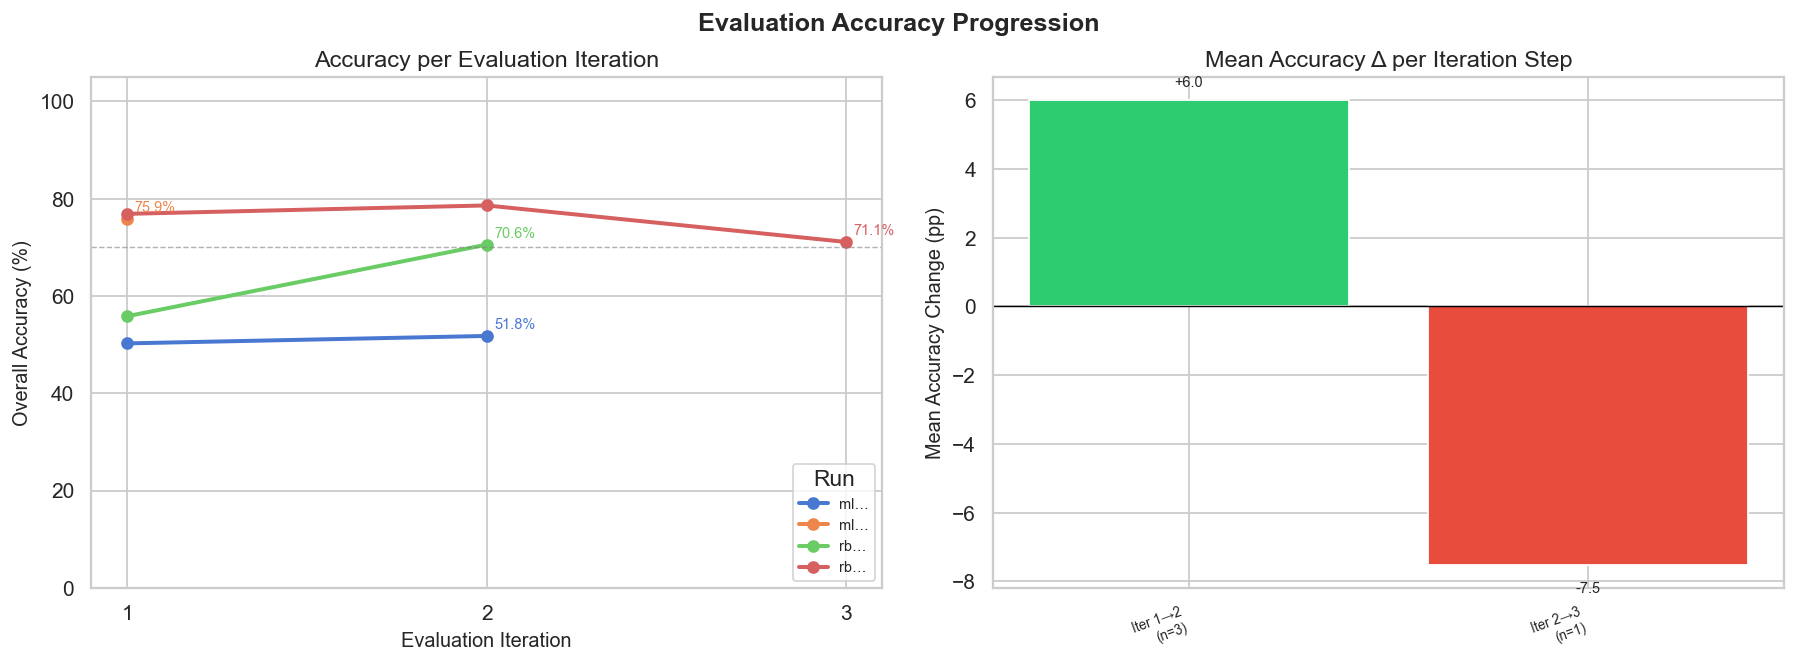

In [6]:
if all_eval.empty or all_eval["accuracy_pct"].isna().all():
    print("⚠️  No accuracy data available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: accuracy per iteration per run ───────────────────────────────────
    ax = axes[0]
    for i, (run_id, grp) in enumerate(all_eval.groupby("run_id")):
        label = run_id.split("_")[-3] + "…" if len(run_id) > 40 else run_id
        grp_sorted = grp.sort_values("eval_iteration")
        ax.plot(grp_sorted["eval_iteration"], grp_sorted["accuracy_pct"],
                marker="o", linewidth=2.2, label=label, color=PALETTE[i % len(PALETTE)])
        # annotate last point
        last = grp_sorted.iloc[-1]
        ax.annotate(f"{last['accuracy_pct']:.1f}%",
                    xy=(last["eval_iteration"], last["accuracy_pct"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8, color=PALETTE[i % len(PALETTE)])

    ax.set_title("Accuracy per Evaluation Iteration")
    ax.set_xlabel("Evaluation Iteration")
    ax.set_ylabel("Overall Accuracy (%)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(title="Run", loc="lower right", fontsize=8)
    ax.set_ylim(0, 105)
    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="70% threshold")

# ── Right: mean delta per iteration step across runs ─────────────────────
    ax2 = axes[1]
    delta_rows = []
    for run_id, grp in all_eval.groupby("run_id"):
        grp_sorted = grp.sort_values("eval_iteration").reset_index(drop=True)
        for j in range(1, len(grp_sorted)):
            prev = grp_sorted.loc[j-1, "accuracy_pct"]
            curr = grp_sorted.loc[j,   "accuracy_pct"]
            if prev is not None and curr is not None:
                delta_rows.append({
                    "run_id": run_id,
                    "step":   f"Iter {j}→{j+1}",
                    "delta":  curr - prev,
                })

    if delta_rows:
        delta_df = pd.DataFrame(delta_rows)
        mean_delta = (delta_df.groupby("step", sort=False)["delta"]
                               .agg(mean_delta="mean", n="count")
                               .reset_index()
                               .sort_values("step"))

        colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in mean_delta["mean_delta"]]
        bars = ax2.bar(range(len(mean_delta)), mean_delta["mean_delta"], color=colors, edgecolor="white")
        ax2.set_xticks(range(len(mean_delta)))
        ax2.set_xticklabels(
            [f"{r['step']}\n(n={r['n']})" for _, r in mean_delta.iterrows()],
            fontsize=7.5, rotation=20, ha="right"
        )
        ax2.axhline(0, color="black", linewidth=0.8)
        ax2.set_title("Mean Accuracy Δ per Iteration Step")
        ax2.set_ylabel("Mean Accuracy Change (pp)")
        for bar, val in zip(bars, mean_delta["mean_delta"]):
            ax2.text(bar.get_x() + bar.get_width()/2,
                     val + (0.3 if val >= 0 else -0.9),
                     f"{val:+.1f}", ha="center", va="bottom", fontsize=8)
    else:
        ax2.set_visible(False)

    plt.tight_layout()
    plt.suptitle("Evaluation Accuracy Progression", y=1.02, fontsize=14, fontweight="bold")
    plt.show()

---
## 4. Node Activity Analysis

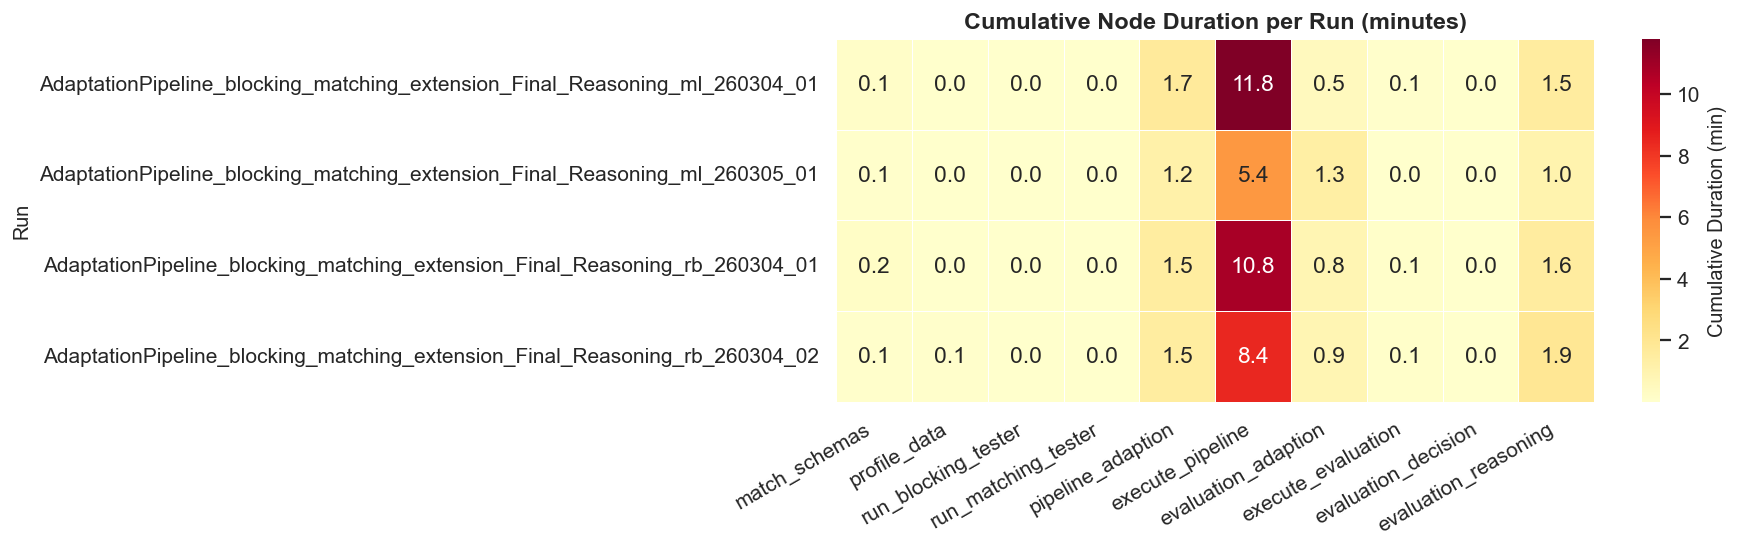

In [7]:
# ── 4a: Node duration heatmap (run × node) ────────────────────────────────────
NODE_ORDER = [
    "match_schemas", "profile_data", "run_blocking_tester", "run_matching_tester",
    "pipeline_adaption", "execute_pipeline",
    "evaluation_adaption", "execute_evaluation",
    "evaluation_decision", "evaluation_reasoning",
]

# Cumulative durations per node per run
tc_rows = []
for run_id, r in runs.items():
    for node, dur in r["time_summary"]["per_node_cumulative"].items():
        tc_rows.append({"run_id": run_id, "node": node, "cumulative_duration_s": dur})

tc_df = pd.DataFrame(tc_rows)

if not tc_df.empty:
    pivot = tc_df.pivot_table(index="run_id", columns="node",
                              values="cumulative_duration_s", aggfunc="sum").fillna(0)
    # reorder columns
    ordered_cols = [c for c in NODE_ORDER if c in pivot.columns] + \
                   [c for c in pivot.columns if c not in NODE_ORDER]
    pivot = pivot[ordered_cols]

    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns)*1.4), max(4, len(pivot)*1.1)))
    sns.heatmap(pivot / 60, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.4,
                linecolor="white", ax=ax, cbar_kws={"label": "Cumulative Duration (min)"})
    ax.set_title("Cumulative Node Duration per Run (minutes)", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Run")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No time complexity data.")

C:\Users\Gregor Debus\AppData\Local\Temp\ipykernel_17236\881802874.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


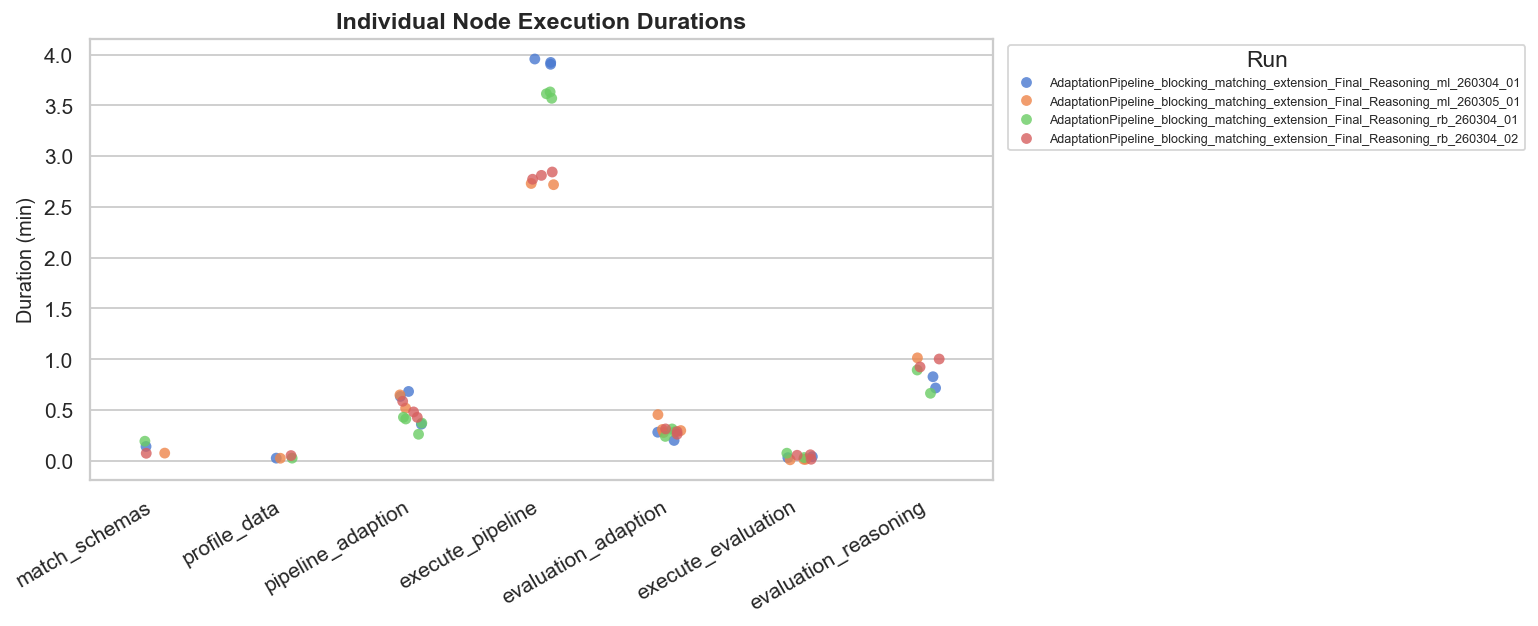

In [8]:
# ── 4b: Individual node durations (scatter / strip) ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

node_dur = all_nodes.copy()
node_dur["duration_min"] = node_dur["duration_seconds"] / 60

# filter out near-zero nodes for readability
visible = node_dur[node_dur["duration_seconds"] > 0.1]

order = [n for n in NODE_ORDER if n in visible["current_node"].unique()] + \
        [n for n in visible["current_node"].unique() if n not in NODE_ORDER]

sns.stripplot(data=visible, x="current_node", y="duration_min",
              hue="run_id", order=order, jitter=True,
              size=6, alpha=0.8, ax=ax)
ax.set_title("Individual Node Execution Durations", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Duration (min)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Run", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

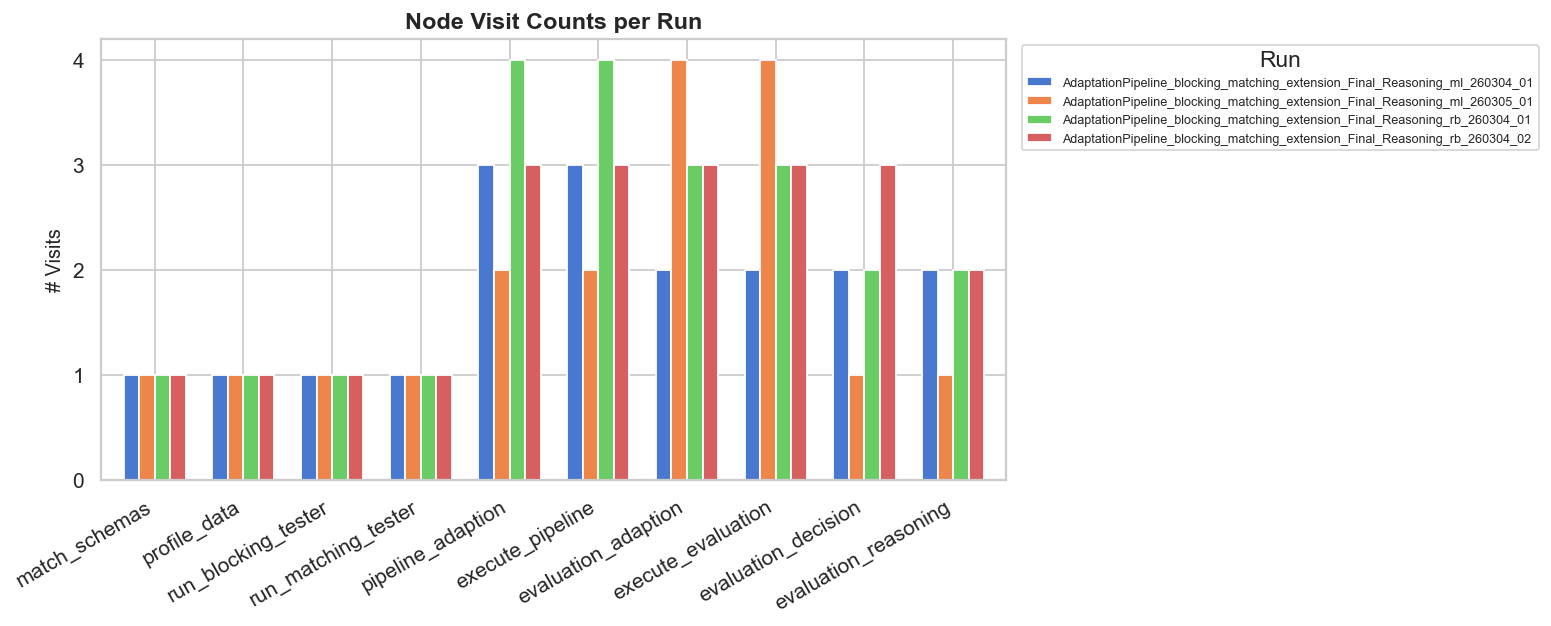

In [9]:
# ── 4c: Node visit counts ──────────────────────────────────────────────────────
visit_counts = (all_nodes.groupby(["run_id", "current_node"])
                         .size().reset_index(name="visits"))

fig, ax = plt.subplots(figsize=(12, 5))
pivot_visits = visit_counts.pivot_table(index="current_node", columns="run_id",
                                        values="visits", aggfunc="sum").fillna(0)
order_v = [n for n in NODE_ORDER if n in pivot_visits.index] + \
          [n for n in pivot_visits.index if n not in NODE_ORDER]
pivot_visits = pivot_visits.reindex(order_v)

pivot_visits.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")
ax.set_title("Node Visit Counts per Run", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("# Visits")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title="Run", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

---
## 5. Token & Cost Analysis

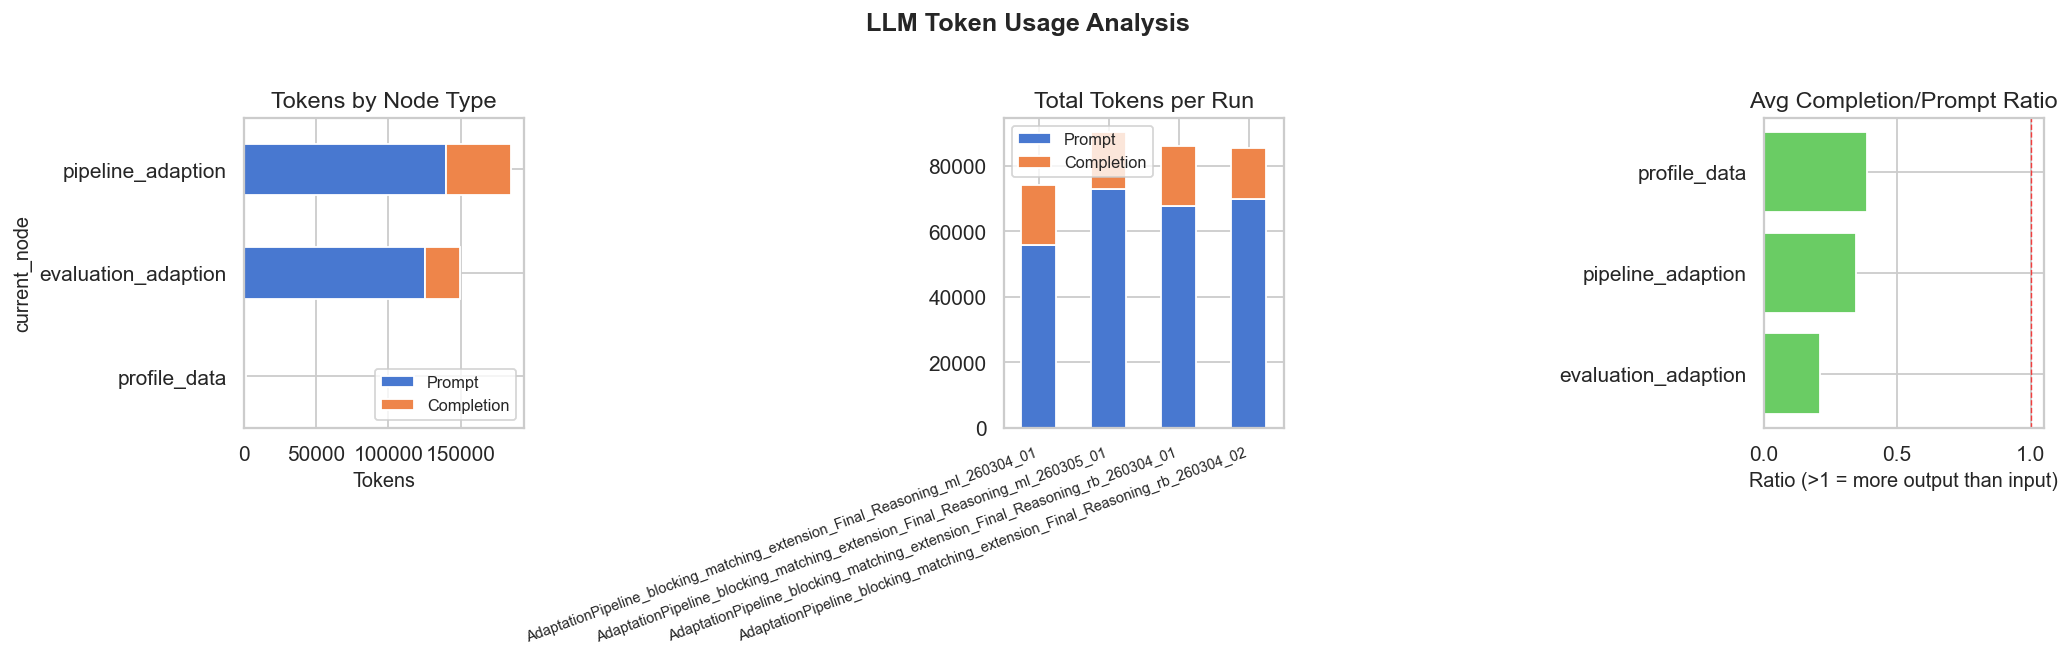

,run_id,prompt_tokens,completion_tokens,total_tokens,prompt_pct
0,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,55760,18408,74168,75.2%
1,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,72862,17233,90095,80.9%
2,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,67664,18383,86047,78.6%
3,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02,69787,15423,85210,81.9%


In [10]:
token_nodes = all_nodes[all_nodes["total_tokens"] > 0].copy()

if token_nodes.empty:
    print("⚠️  No token data found in logs.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── 5a: Tokens per node type (stacked prompt / completion) ─────────────────
    ax = axes[0]
    tok_by_node = (token_nodes.groupby("current_node")[["prompt_tokens","completion_tokens"]]
                              .sum().sort_values("prompt_tokens", ascending=True))
    tok_by_node.plot(kind="barh", stacked=True, ax=ax,
                     color=[PALETTE[0], PALETTE[1]], edgecolor="white")
    ax.set_title("Tokens by Node Type")
    ax.set_xlabel("Tokens")
    ax.legend(["Prompt", "Completion"], loc="lower right")

    # ── 5b: Token usage per run ────────────────────────────────────────────────
    ax2 = axes[1]
    tok_by_run = (token_nodes.groupby("run_id")[["prompt_tokens","completion_tokens"]]
                             .sum())
    tok_by_run.plot(kind="bar", stacked=True, ax=ax2,
                    color=[PALETTE[0], PALETTE[1]], edgecolor="white")
    ax2.set_title("Total Tokens per Run")
    ax2.set_xlabel("")
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right", fontsize=8)
    ax2.legend(["Prompt", "Completion"])

    # ── 5c: Prompt-to-completion ratio ─────────────────────────────────────────
    ax3 = axes[2]
    token_nodes["ratio"] = (
        token_nodes["completion_tokens"] /
        token_nodes["prompt_tokens"].replace(0, np.nan)
    )
    ratio_by_node = token_nodes.groupby("current_node")["ratio"].mean().sort_values()
    bars = ax3.barh(ratio_by_node.index, ratio_by_node.values,
                    color=PALETTE[2], edgecolor="white")
    ax3.axvline(1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax3.set_title("Avg Completion/Prompt Ratio")
    ax3.set_xlabel("Ratio (>1 = more output than input)")

    plt.suptitle("LLM Token Usage Analysis", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary table
    tok_summary = (all_nodes.groupby("run_id")[["prompt_tokens","completion_tokens","total_tokens"]]
                            .sum().reset_index())
    tok_summary["prompt_pct"] = (tok_summary["prompt_tokens"] / tok_summary["total_tokens"] * 100).round(1)
    display(tok_summary.style
            .background_gradient(subset=["total_tokens"], cmap="Blues")
            .format({"prompt_pct": "{:.1f}%"})
            .set_caption("Token Summary per Run"))

---
## 6. Transition Graph Visualisation

C:\Users\Gregor Debus\AppData\Local\Temp\ipykernel_8168\3163445492.py:71: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
D:\Studium\Master\Semester 5\Team Project\workspace\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


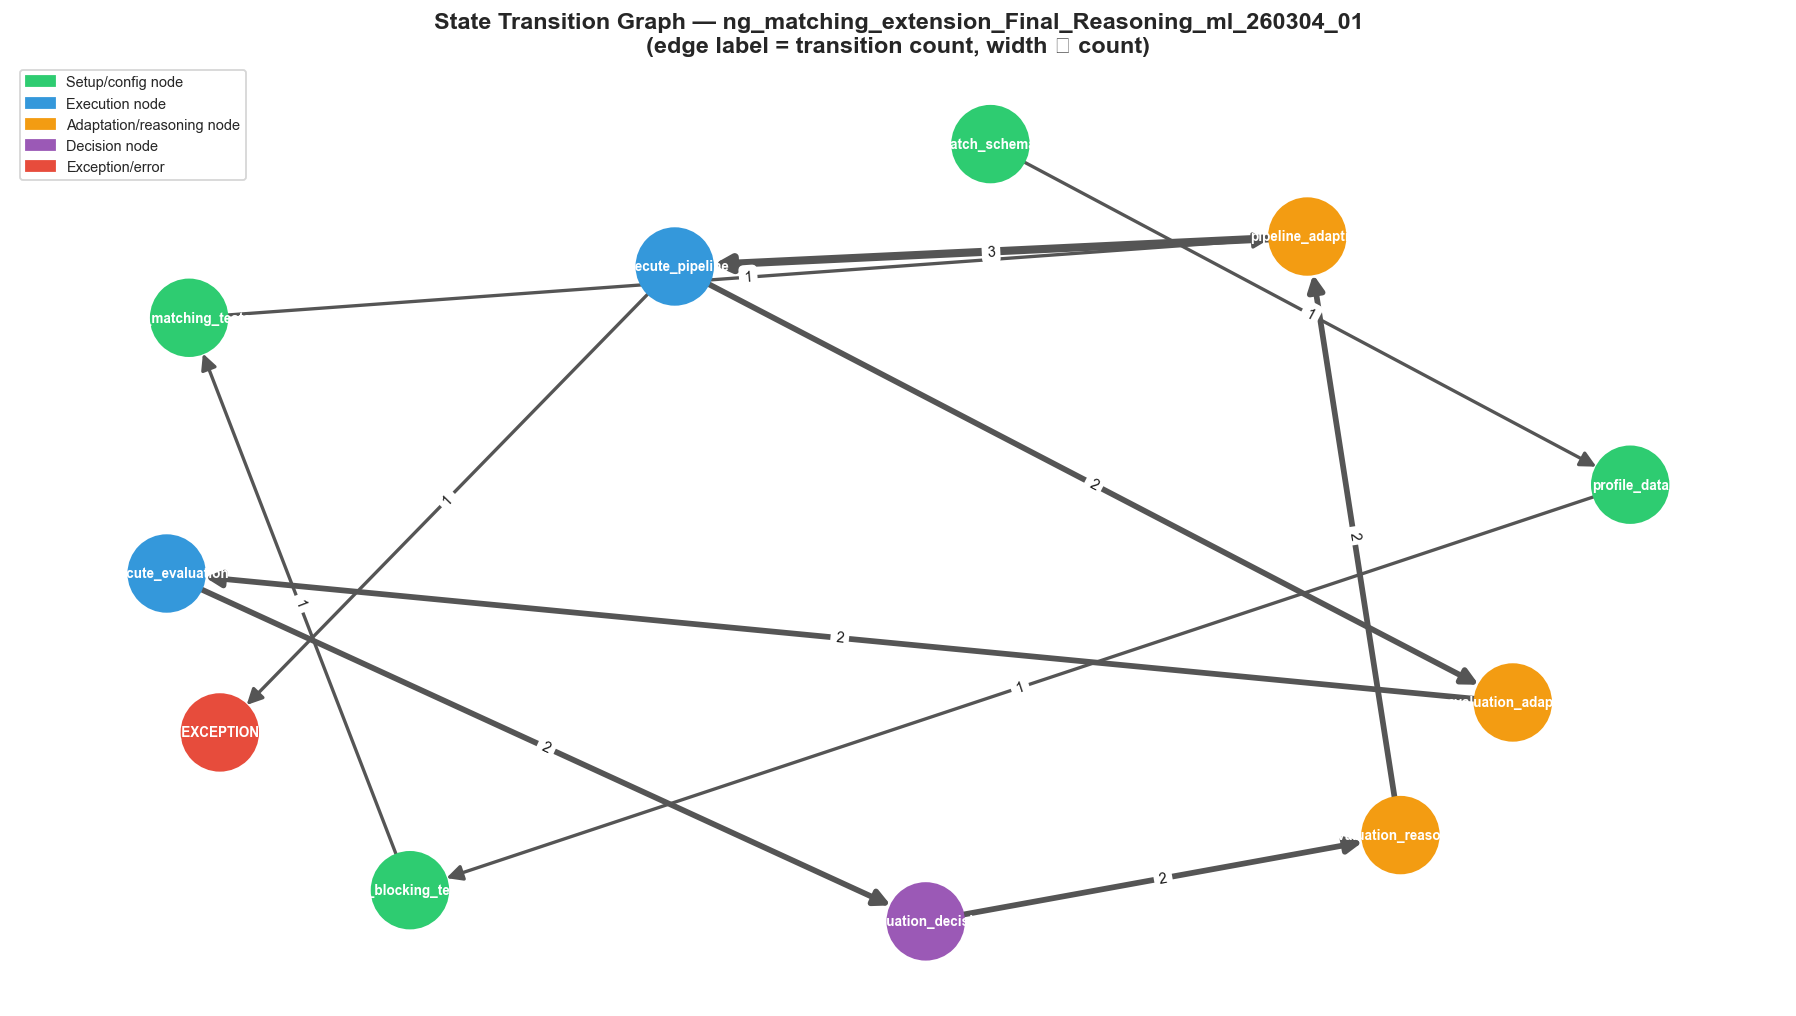

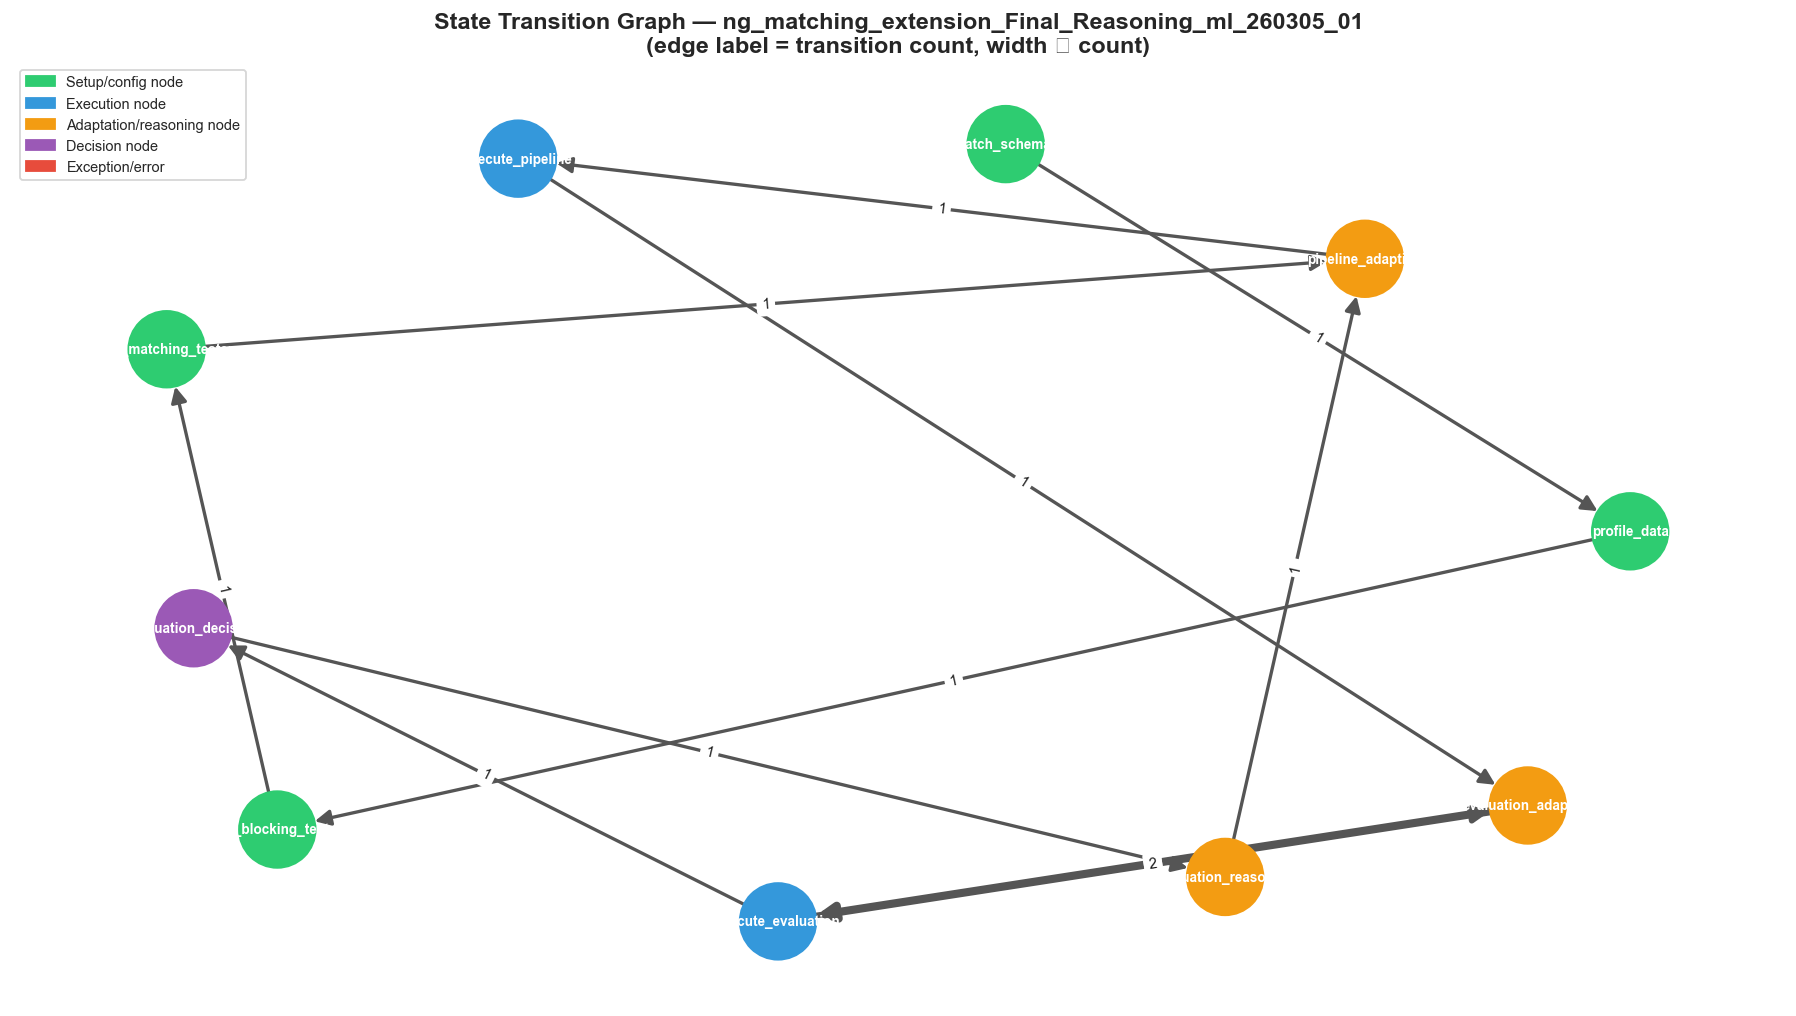

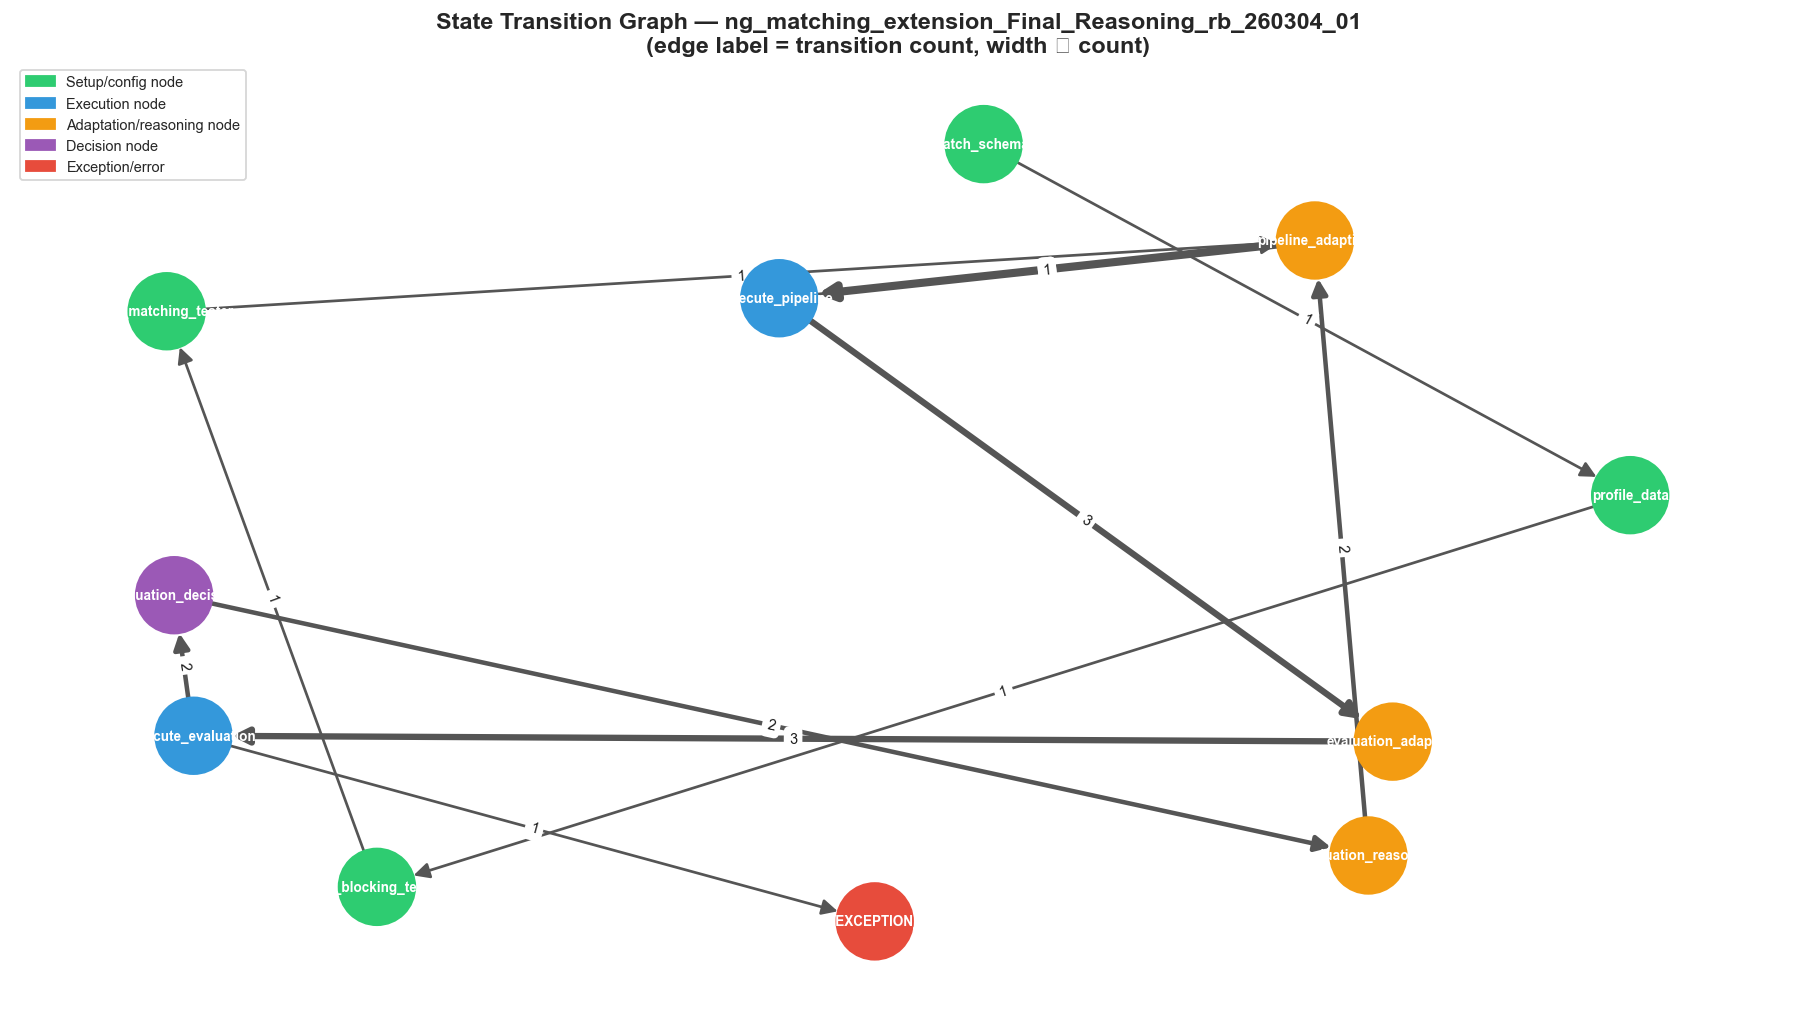

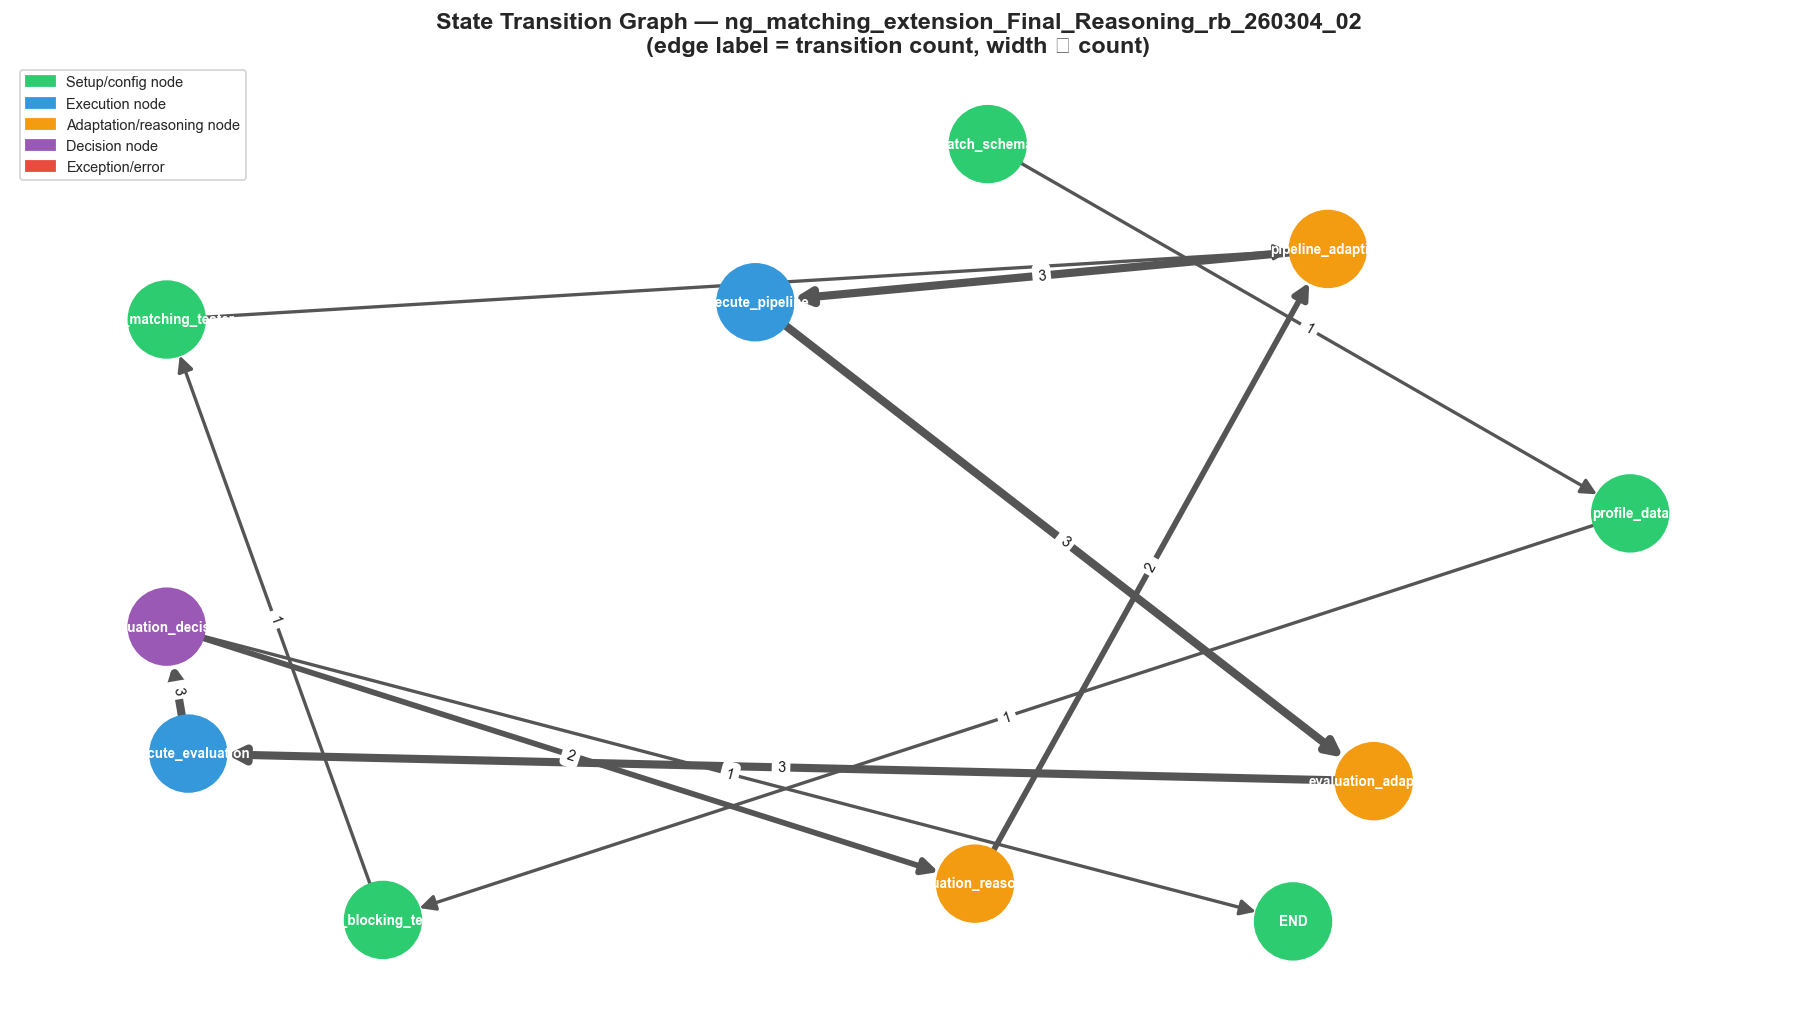

In [44]:
try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False
    print("networkx not installed — run `pip install networkx` for graph visualisation.")

if HAS_NX:
    for run_id, r in runs.items():
        tc_raw = r["transition_summary"]["transition_counts"]
        if not tc_raw:
            continue

        G = nx.DiGraph()
        edge_labels = {}
        max_weight  = 1

        for src, targets in tc_raw.items():
            for tgt, cnt in targets.items():
                G.add_edge(src, tgt, weight=cnt)
                edge_labels[(src, tgt)] = str(cnt)
                max_weight = max(max_weight, cnt)

        # colour scheme
        node_colors = []
        for n in G.nodes:
            if "exception" in n.lower() or "error" in n.lower():
                node_colors.append("#e74c3c")
            elif n in ("execute_pipeline", "execute_evaluation"):
                node_colors.append("#3498db")
            elif "adaption" in n or "reasoning" in n:
                node_colors.append("#f39c12")
            elif "decision" in n:
                node_colors.append("#9b59b6")
            else:
                node_colors.append("#2ecc71")

        # layout: try hierarchical, fall back to spring
        try:
            pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
        except Exception:
            pos = nx.spring_layout(G, seed=42, k=2.5)

        edge_widths = [G[u][v]["weight"] / max_weight * 4 + 0.5
                       for u, v in G.edges()]

        short_id = run_id[-50:]
        fig, ax = plt.subplots(figsize=(14, 8))
        nx.draw_networkx(
            G, pos=pos, ax=ax,
            node_color=node_colors, node_size=1800,
            font_size=7.5, font_color="white", font_weight="bold",
            edge_color="#555", arrows=True, arrowsize=18,
            width=edge_widths,
        )
        nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels,
                                     font_size=8, ax=ax)

        legend_patches = [
            mpatches.Patch(color="#2ecc71",  label="Setup/config node"),
            mpatches.Patch(color="#3498db",  label="Execution node"),
            mpatches.Patch(color="#f39c12",  label="Adaptation/reasoning node"),
            mpatches.Patch(color="#9b59b6",  label="Decision node"),
            mpatches.Patch(color="#e74c3c",  label="Exception/error"),
        ]
        ax.legend(handles=legend_patches, loc="upper left", fontsize=8)
        ax.set_title(f"State Transition Graph — {short_id}\n"
                     f"(edge label = transition count, width ∝ count)",
                     fontweight="bold")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

---
## 7. Blocking Configuration Analysis

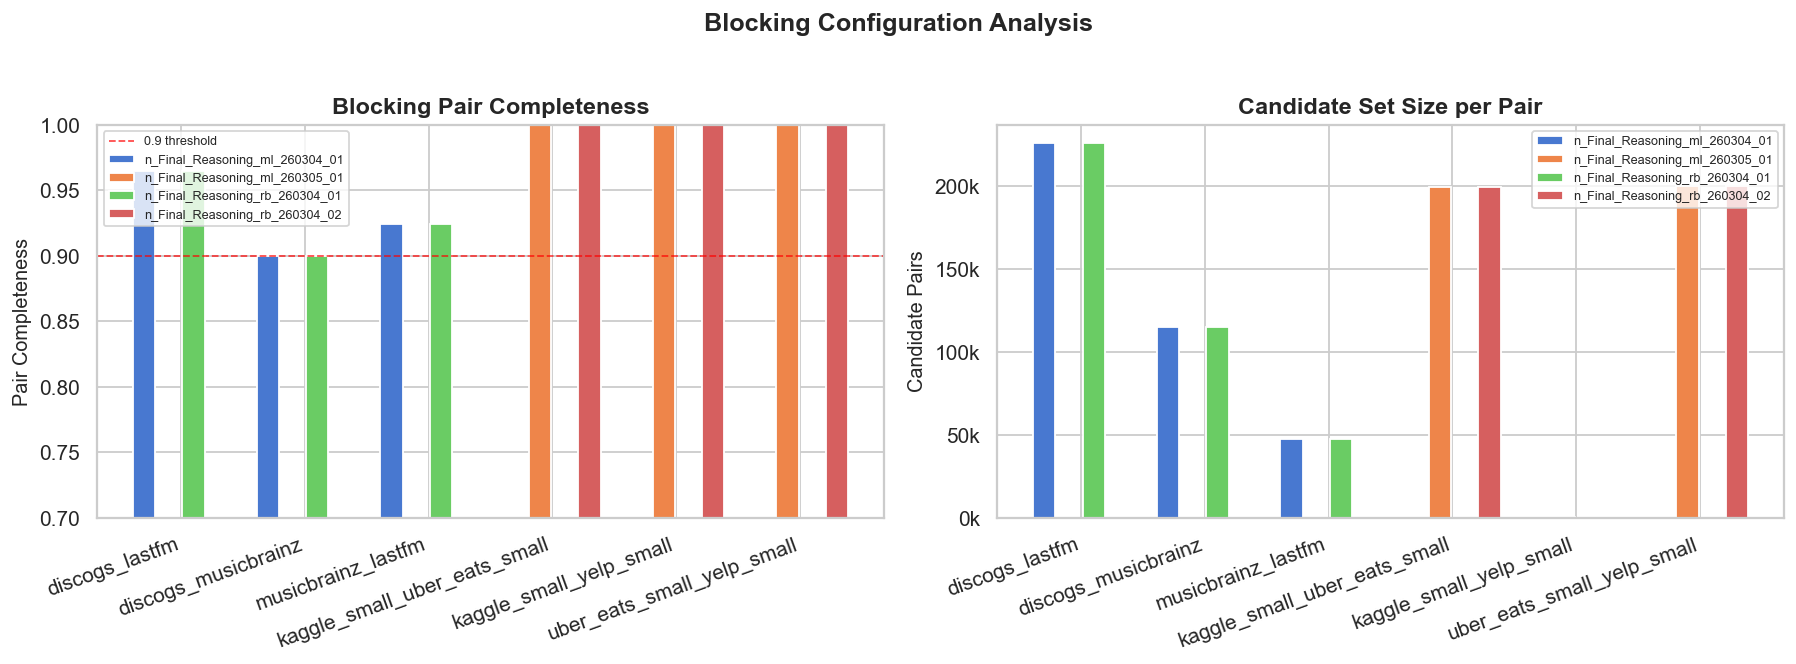

,run_id,pair,strategy,columns,pair_completeness,num_candidates,is_acceptable
0,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,discogs_lastfm,semantic_similarity,"name, artist",0.964,225831,True
1,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,discogs_musicbrainz,sorted_neighbourhood,name,0.900,115280,True
2,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,musicbrainz_lastfm,semantic_similarity,"name, artist, duration",0.924,47615,True
3,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,kaggle_small_uber_eats_small,semantic_similarity,"name_norm, city, state",1.000,199719,True
4,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,kaggle_small_yelp_small,exact_match_multi,"phone_e164, postal_code",1.000,179,True
5,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,uber_eats_small_yelp_small,semantic_similarity,"name_norm, street, city",1.000,199972,True
6,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,discogs_lastfm,semantic_similarity,"name, artist",0.964,225831,True
7,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,discogs_musicbrainz,sorted_neighbourhood,name,0.900,115280,True
8,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,musicbrainz_lastfm,semantic_similarity,"name, artist, duration",0.924,47615,True
9,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02,kaggle_small_uber_eats_small,semantic_similarity,"name_norm, city, state",1.000,199719,True


In [45]:
if all_blocking.empty:
    print("⚠️  No blocking config data.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── 7a: Pair completeness per pair × run ───────────────────────────────────
    ax = axes[0]
    pairs = all_blocking["pair"].unique()
    x = np.arange(len(pairs))
    run_ids = all_blocking["run_id"].unique()
    width = 0.8 / max(len(run_ids), 1)

    for i, rid in enumerate(run_ids):
        sub = all_blocking[all_blocking["run_id"] == rid]
        vals = [sub[sub["pair"] == p]["pair_completeness"].mean() for p in pairs]
        offset = (i - len(run_ids)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width=width*0.9,
                      label=rid[-30:], color=PALETTE[i % len(PALETTE)], edgecolor="white")

    ax.axhline(0.9, color="red", linestyle="--", linewidth=1, alpha=0.7, label="0.9 threshold")
    ax.set_xticks(x)
    ax.set_xticklabels(pairs, rotation=20, ha="right")
    ax.set_ylabel("Pair Completeness")
    ax.set_title("Blocking Pair Completeness", fontweight="bold")
    ax.set_ylim(0.7, 1.0)
    ax.legend(fontsize=7)

    # ── 7b: Candidate set sizes ────────────────────────────────────────────────
    ax2 = axes[1]
    for i, rid in enumerate(run_ids):
        sub = all_blocking[all_blocking["run_id"] == rid]
        vals = [sub[sub["pair"] == p]["num_candidates"].mean() for p in pairs]
        offset = (i - len(run_ids)/2 + 0.5) * width
        ax2.bar(x + offset, vals, width=width*0.9,
                label=rid[-30:], color=PALETTE[i % len(PALETTE)], edgecolor="white")

    ax2.set_xticks(x)
    ax2.set_xticklabels(pairs, rotation=20, ha="right")
    ax2.set_ylabel("Candidate Pairs")
    ax2.set_title("Candidate Set Size per Pair", fontweight="bold")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
    ax2.legend(fontsize=7)

    plt.suptitle("Blocking Configuration Analysis", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # Pretty table
    display(all_blocking[["run_id","pair","strategy","columns",
                           "pair_completeness","num_candidates","is_acceptable"]]
            .style
            .background_gradient(subset=["pair_completeness"], cmap="YlGn", vmin=0.7, vmax=1.0)
            .background_gradient(subset=["num_candidates"],    cmap="Blues")
            .format({"pair_completeness": "{:.3f}"})
            .set_caption("Blocking Configuration Details"))

---
## 8. Matching Configuration & F1 Scores

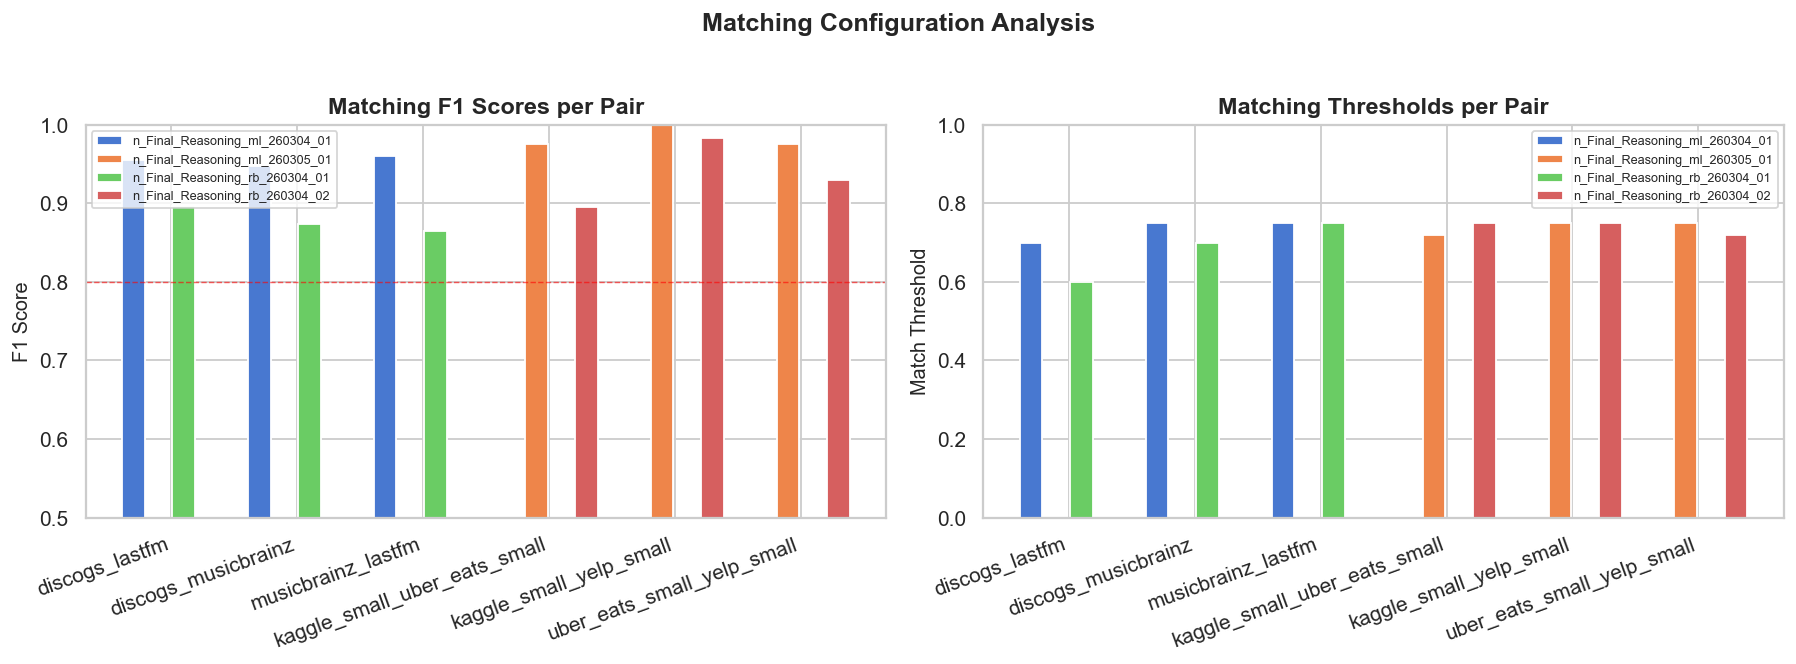

,run_id,pair,threshold,f1,n_comparators
0,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,discogs_lastfm,0.70,0.9550,4
1,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,discogs_musicbrainz,0.75,0.9474,6
2,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,musicbrainz_lastfm,0.75,0.9605,4
3,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,kaggle_small_uber_eats_small,0.72,0.9756,6
4,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,kaggle_small_yelp_small,0.75,1.0000,6
5,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,uber_eats_small_yelp_small,0.75,0.9756,7
6,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,discogs_lastfm,0.60,0.8966,4
7,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,discogs_musicbrainz,0.70,0.8732,5
8,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,musicbrainz_lastfm,0.75,0.8652,3
9,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02,kaggle_small_uber_eats_small,0.75,0.8947,7


In [46]:
if all_matching.empty:
    print("⚠️  No matching config data.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pairs_m = all_matching["pair"].unique()
    run_ids_m = all_matching["run_id"].unique()
    x = np.arange(len(pairs_m))
    width = 0.8 / max(len(run_ids_m), 1)

    # ── 8a: F1 scores ─────────────────────────────────────────────────────────
    ax = axes[0]
    for i, rid in enumerate(run_ids_m):
        sub = all_matching[all_matching["run_id"] == rid]
        vals = [sub[sub["pair"] == p]["f1"].mean() for p in pairs_m]
        offset = (i - len(run_ids_m)/2 + 0.5) * width
        ax.bar(x + offset, vals, width=width*0.9,
               label=rid[-30:], color=PALETTE[i % len(PALETTE)], edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(pairs_m, rotation=20, ha="right")
    ax.set_ylabel("F1 Score")
    ax.set_title("Matching F1 Scores per Pair", fontweight="bold")
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.8, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=7)

    # ── 8b: Thresholds ────────────────────────────────────────────────────────
    ax2 = axes[1]
    for i, rid in enumerate(run_ids_m):
        sub = all_matching[all_matching["run_id"] == rid]
        vals = [sub[sub["pair"] == p]["threshold"].mean() for p in pairs_m]
        offset = (i - len(run_ids_m)/2 + 0.5) * width
        ax2.bar(x + offset, vals, width=width*0.9,
                label=rid[-30:], color=PALETTE[i % len(PALETTE)], edgecolor="white")

    ax2.set_xticks(x)
    ax2.set_xticklabels(pairs_m, rotation=20, ha="right")
    ax2.set_ylabel("Match Threshold")
    ax2.set_title("Matching Thresholds per Pair", fontweight="bold")
    ax2.set_ylim(0, 1)
    ax2.legend(fontsize=7)

    plt.suptitle("Matching Configuration Analysis", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    display(all_matching[["run_id","pair","threshold","f1","n_comparators"]]
            .style
            .background_gradient(subset=["f1"], cmap="YlGn", vmin=0.5, vmax=1.0)
            .format({"f1": "{:.4f}", "threshold": "{:.2f}"})
            .set_caption("Matching Strategy Details"))

---
## 9. Fusion Strategy Evolution

C:\Users\Gregor Debus\AppData\Local\Temp\ipykernel_8168\1522535456.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  fuser_coded = fuser_df[attr_cols].applymap(
C:\Users\Gregor Debus\AppData\Local\Temp\ipykernel_8168\1522535456.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(all_fusers))


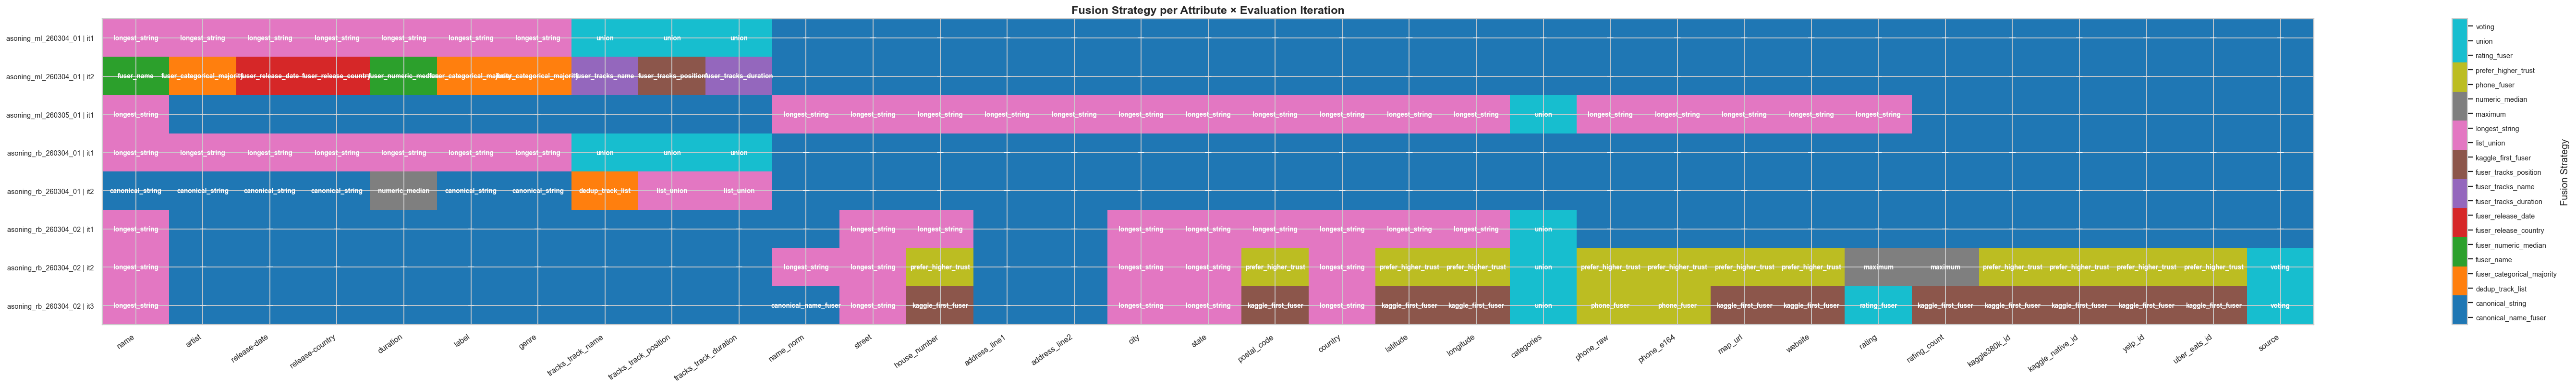

,run_id,eval_iteration,accuracy_pct,name,artist,release-date,release-country,duration,label,genre,tracks_track_name,tracks_track_position,tracks_track_duration,name_norm,street,house_number,address_line1,address_line2,city,state,postal_code,country,latitude,longitude,categories,phone_raw,phone_e164,map_url,website,rating,rating_count,kaggle380k_id,kaggle_native_id,yelp_id,uber_eats_id,source
0,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,1,50.25%,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,union,union,union,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
1,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260304_01,2,51.78%,fuser_name,fuser_categorical_majority,fuser_release_date,fuser_release_country,fuser_numeric_median,fuser_categorical_majority,fuser_categorical_majority,fuser_tracks_name,fuser_tracks_position,fuser_tracks_duration,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
2,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_ml_260305_01,1,75.92%,longest_string,—,—,—,—,—,—,—,—,—,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,union,longest_string,longest_string,longest_string,longest_string,longest_string,—,—,—,—,—,—
3,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,1,55.84%,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,union,union,union,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
4,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_01,2,70.56%,canonical_string,canonical_string,canonical_string,canonical_string,numeric_median,canonical_string,canonical_string,dedup_track_list,list_union,list_union,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
5,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02,1,76.88%,longest_string,—,—,—,—,—,—,—,—,—,—,longest_string,longest_string,—,—,longest_string,longest_string,longest_string,longest_string,longest_string,longest_string,union,—,—,—,—,—,—,—,—,—,—,—
6,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02,2,78.61%,longest_string,—,—,—,—,—,—,—,—,—,longest_string,longest_string,prefer_higher_trust,—,—,longest_string,longest_string,prefer_higher_trust,longest_string,prefer_higher_trust,prefer_higher_trust,union,prefer_higher_trust,prefer_higher_trust,prefer_higher_trust,prefer_higher_trust,maximum,maximum,prefer_higher_trust,prefer_higher_trust,prefer_higher_trust,prefer_higher_trust,voting
7,AdaptationPipeline_blocking_matching_extension_Final_Reasoning_rb_260304_02,3,71.10%,longest_string,—,—,—,—,—,—,—,—,—,canonical_name_fuser,longest_string,kaggle_first_fuser,—,—,longest_string,longest_string,kaggle_first_fuser,longest_string,kaggle_first_fuser,kaggle_first_fuser,union,phone_fuser,phone_fuser,kaggle_first_fuser,kaggle_first_fuser,rating_fuser,kaggle_first_fuser,kaggle_first_fuser,kaggle_first_fuser,kaggle_first_fuser,kaggle_first_fuser,voting


In [47]:
if all_eval.empty:
    print("⚠️  No evaluation run data.")
else:
    # Build fuser matrix: rows = (run × eval_iter), columns = attributes
    fuser_rows = []
    for _, row in all_eval.iterrows():
        base = {"run_id": row["run_id"], "eval_iteration": row["eval_iteration"],
                "accuracy_pct": row["accuracy_pct"]}
        base.update(row["attribute_fusers"])
        fuser_rows.append(base)

    fuser_df = pd.DataFrame(fuser_rows)
    attr_cols = [c for c in fuser_df.columns
                 if c not in ("run_id","eval_iteration","accuracy_pct")]

    if attr_cols:
        # Encode fusers as categorical codes for heatmap
        all_fusers = sorted(set(
            v for c in attr_cols for v in fuser_df[c].dropna().unique()
        ))
        fuser_to_int = {f: i for i, f in enumerate(all_fusers)}
        int_to_fuser = {i: f for f, i in fuser_to_int.items()}

        fuser_coded = fuser_df[attr_cols].applymap(
            lambda x: fuser_to_int.get(x, -1) if pd.notna(x) else -1
        )
        fuser_coded.index = [
            f"{r['run_id'][-20:]} | it{r['eval_iteration']}"
            for _, r in fuser_df.iterrows()
        ]

        cmap = plt.cm.get_cmap("tab10", len(all_fusers))
        fig, ax = plt.subplots(figsize=(max(10, len(attr_cols)*1.4),
                                        max(4, len(fuser_df)*0.8)))
        im = ax.imshow(fuser_coded.values, aspect="auto",
                       cmap=cmap, vmin=-0.5, vmax=len(all_fusers)-0.5)

        # annotate cells
        for r_idx in range(fuser_coded.shape[0]):
            for c_idx in range(fuser_coded.shape[1]):
                code = fuser_coded.iloc[r_idx, c_idx]
                name = int_to_fuser.get(code, "—")
                ax.text(c_idx, r_idx, name, ha="center", va="center",
                        fontsize=7.5, color="white",
                        fontweight="bold" if code >= 0 else "normal")

        cbar = plt.colorbar(im, ax=ax, ticks=range(len(all_fusers)))
        cbar.ax.set_yticklabels(all_fusers, fontsize=8)
        cbar.set_label("Fusion Strategy")

        ax.set_xticks(range(len(attr_cols)))
        ax.set_xticklabels(attr_cols, rotation=35, ha="right", fontsize=9)
        ax.set_yticks(range(len(fuser_df)))
        ax.set_yticklabels(fuser_coded.index, fontsize=8)
        ax.set_title("Fusion Strategy per Attribute × Evaluation Iteration",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

        # Show accuracy alongside
        fuser_display = fuser_df[["run_id","eval_iteration","accuracy_pct"] + attr_cols]
        display(fuser_display.style
                .background_gradient(subset=["accuracy_pct"], cmap="YlGn", vmin=40, vmax=100)
                .format({"accuracy_pct": "{:.2f}%"}, na_rep="—")
                .set_caption("Fusion Strategy Evolution"))

---
## 10. Error & Retry Analysis

In [48]:
# ── 10a: Exception transitions ────────────────────────────────────────────────
exceptions = all_nodes[all_nodes["next_node"].str.contains("EXCEPTION", na=False)].copy()

# ── 10b: Failed pipeline / evaluation executions ──────────────────────────────
failed_exec = all_nodes[
    all_nodes["output_summary"].str.contains("failed", case=False, na=False)
].copy()

print(f"Exception transitions found : {len(exceptions)}")
print(f"Failed execution nodes      : {len(failed_exec)}")

if not exceptions.empty:
    print("\n── Exception nodes:")
    display(exceptions[["run_id","node_index","current_node","next_node",
                         "duration_seconds","output_summary"]])

if not failed_exec.empty:
    print("\n── Failed execution summaries:")
    display(failed_exec[["run_id","node_index","current_node","output_summary"]])

Exception transitions found : 2
Failed execution nodes      : 5

── Exception nodes:


,run_id,node_index,current_node,next_node,duration_seconds,output_summary
17,AdaptationPipeline_blocking_matching_extension...,18,execute_pipeline,__EXCEPTION__,234.248,pipeline execution succeeded on attempt 1; fus...
54,AdaptationPipeline_blocking_matching_extension...,22,execute_evaluation,__EXCEPTION__,0.039,evaluation execution failed on attempt 1: erro...



── Failed execution summaries:


,run_id,node_index,current_node,output_summary
25,AdaptationPipeline_blocking_matching_extension...,8,execute_evaluation,evaluation execution failed on attempt 1: erro...
26,AdaptationPipeline_blocking_matching_extension...,9,evaluation_adaption,This run was a repair of the evaluation script...
27,AdaptationPipeline_blocking_matching_extension...,10,execute_evaluation,evaluation execution failed on attempt 2: erro...
50,AdaptationPipeline_blocking_matching_extension...,18,execute_pipeline,pipeline execution failed on attempt 1: error:...
54,AdaptationPipeline_blocking_matching_extension...,22,execute_evaluation,evaluation execution failed on attempt 1: erro...


In [49]:
# ── 10c: Retry pattern — how many times execute_pipeline was visited ──────────
retry_info = []
for run_id, r in runs.items():
    tc = r["transition_summary"]["transition_counts"]
    pipe_visits   = sum(tc.get("pipeline_adaption", {}).get("execute_pipeline", 0) for _ in [1])
    # Use node visit count directly
    nodes_df = r["nodes"]
    ep_visits = len(nodes_df[nodes_df["current_node"] == "execute_pipeline"])
    ee_visits = len(nodes_df[nodes_df["current_node"] == "execute_evaluation"])
    exc_visits = len(nodes_df[nodes_df["next_node"].str.contains("EXCEPTION", na=False)])
    retry_info.append({
        "run_id":                  run_id[-50:],
        "execute_pipeline visits": ep_visits,
        "execute_evaluation visits": ee_visits,
        "exception transitions":   exc_visits,
        "pipeline_adaption visits":len(nodes_df[nodes_df["current_node"]=="pipeline_adaption"]),
        "evaluation_reasoning visits": len(nodes_df[nodes_df["current_node"]=="evaluation_reasoning"]),
    })

retry_df = pd.DataFrame(retry_info)
display(retry_df.style
        .background_gradient(subset=["execute_pipeline visits",
                                      "execute_evaluation visits",
                                      "pipeline_adaption visits"], cmap="YlOrRd")
        .background_gradient(subset=["exception transitions"], cmap="Reds")
        .set_caption("Retry & Iteration Counts per Run"))

,run_id,execute_pipeline visits,execute_evaluation visits,exception transitions,pipeline_adaption visits,evaluation_reasoning visits
0,ng_matching_extension_Final_Reasoning_ml_260304_01,3,2,1,3,2
1,ng_matching_extension_Final_Reasoning_ml_260305_01,1,3,0,2,1
2,ng_matching_extension_Final_Reasoning_rb_260304_01,4,3,1,4,2
3,ng_matching_extension_Final_Reasoning_rb_260304_02,3,3,0,3,2


---
## 12. Detailed Node Timeline per Run

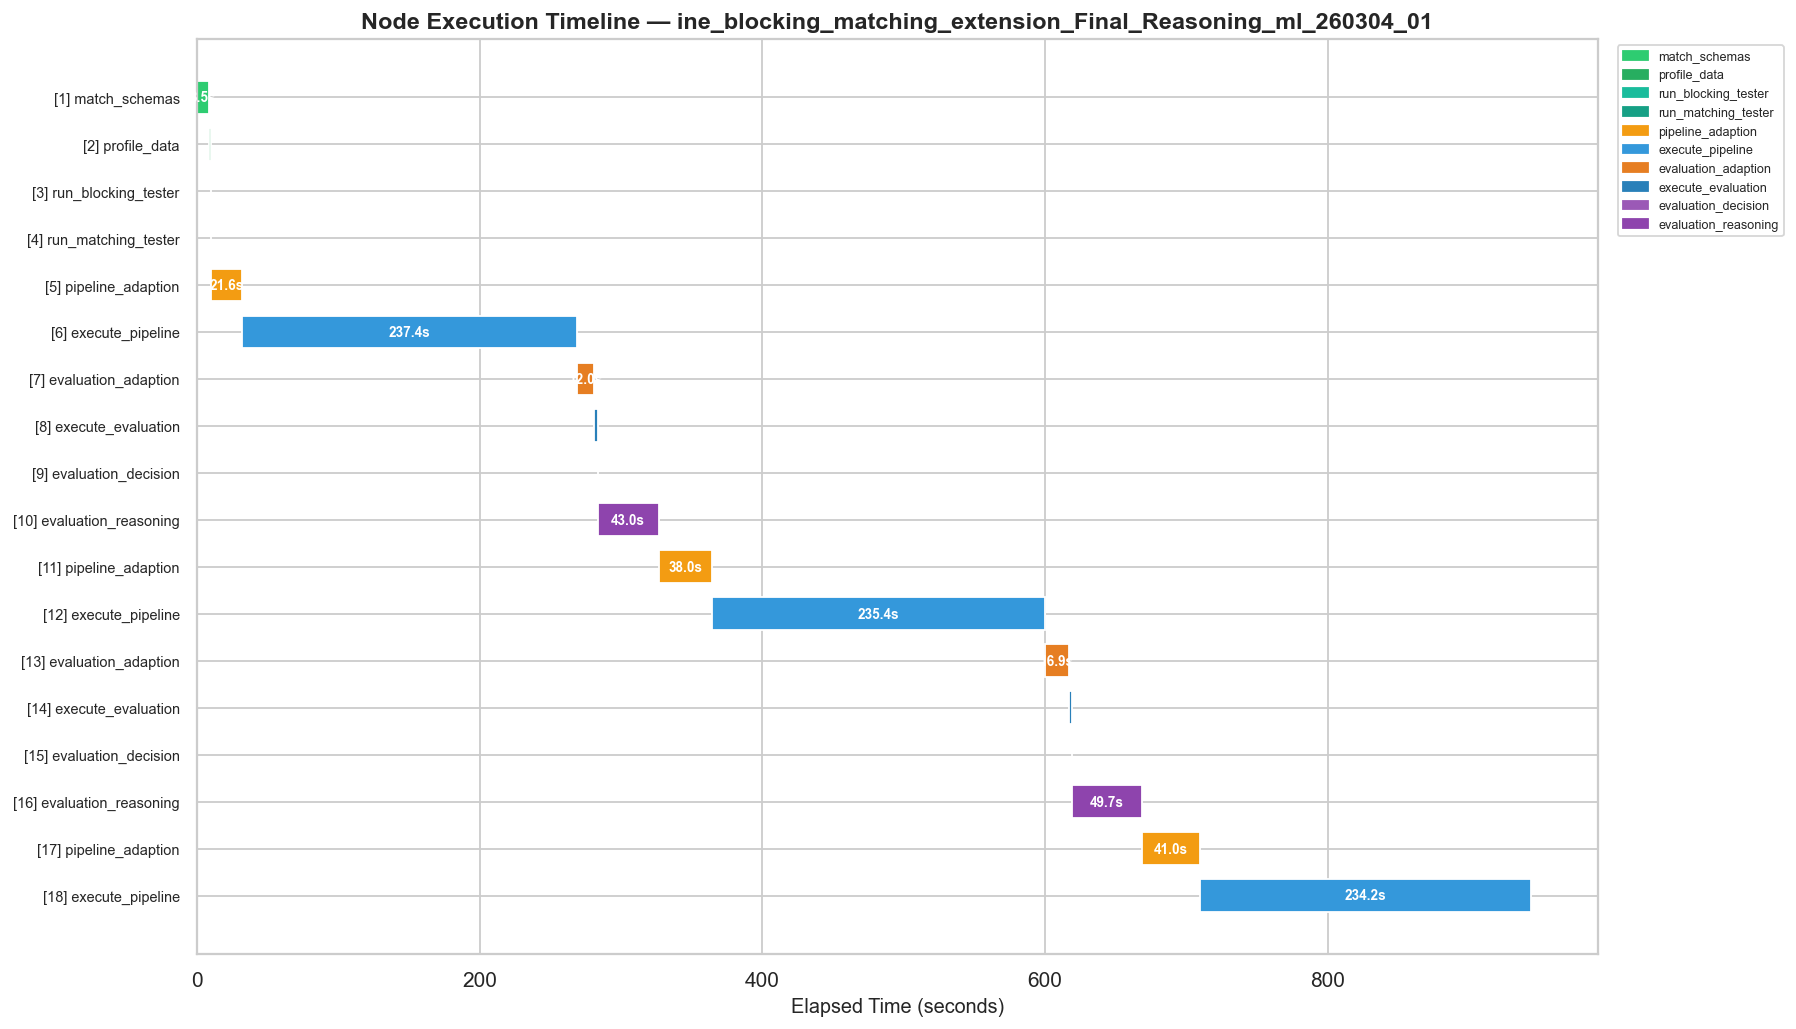

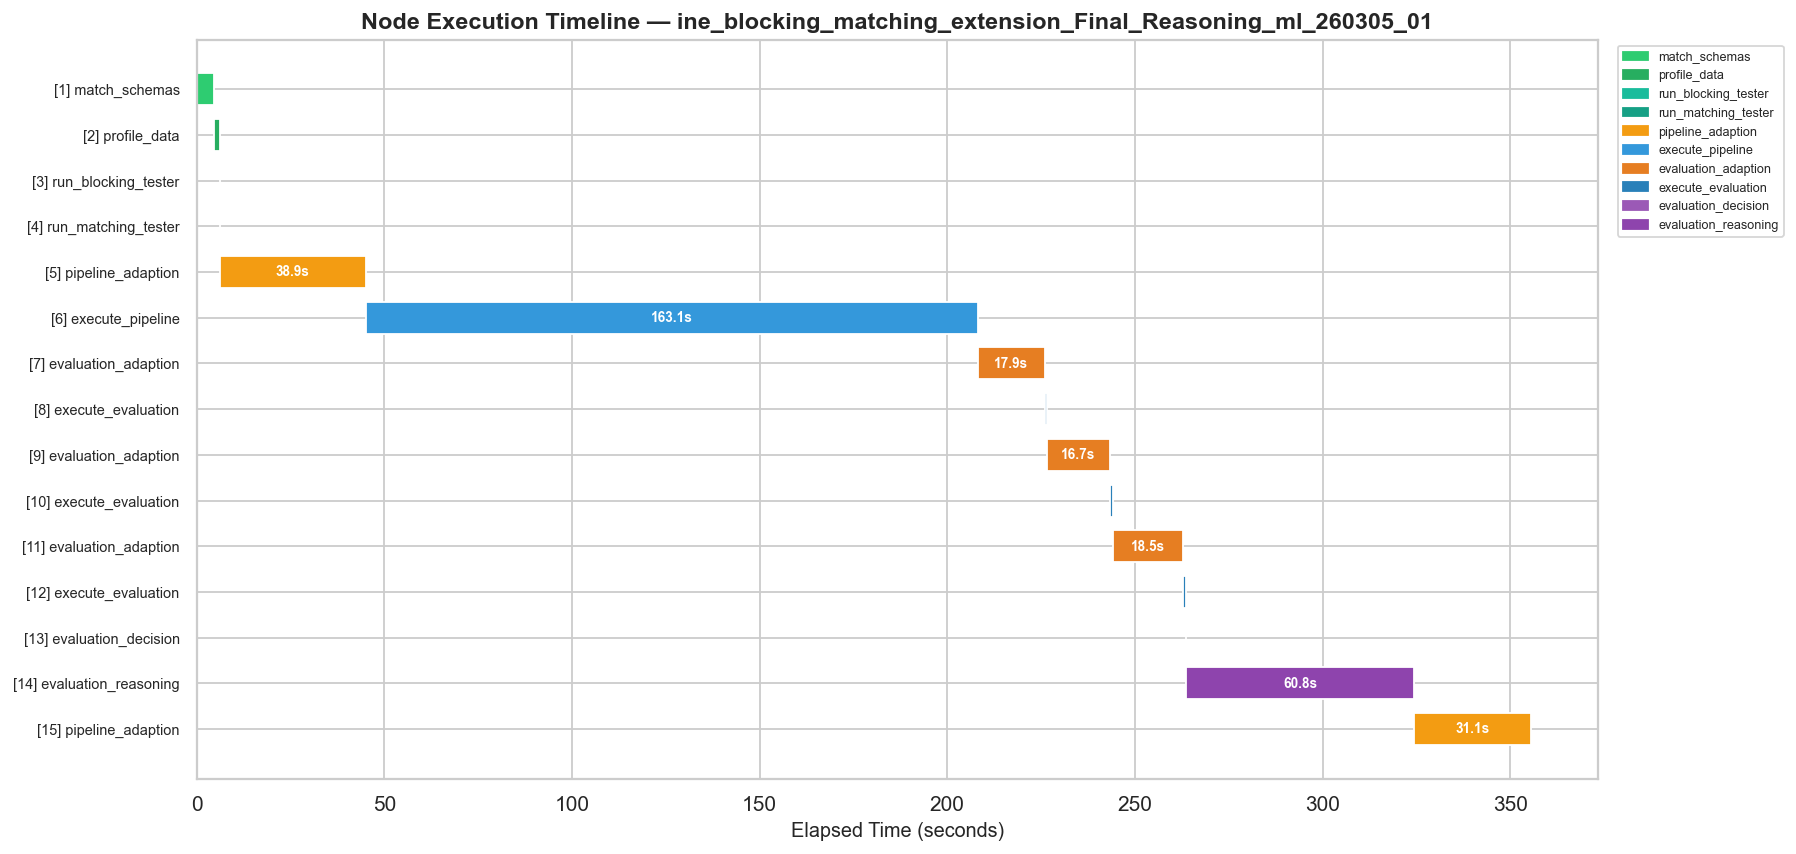

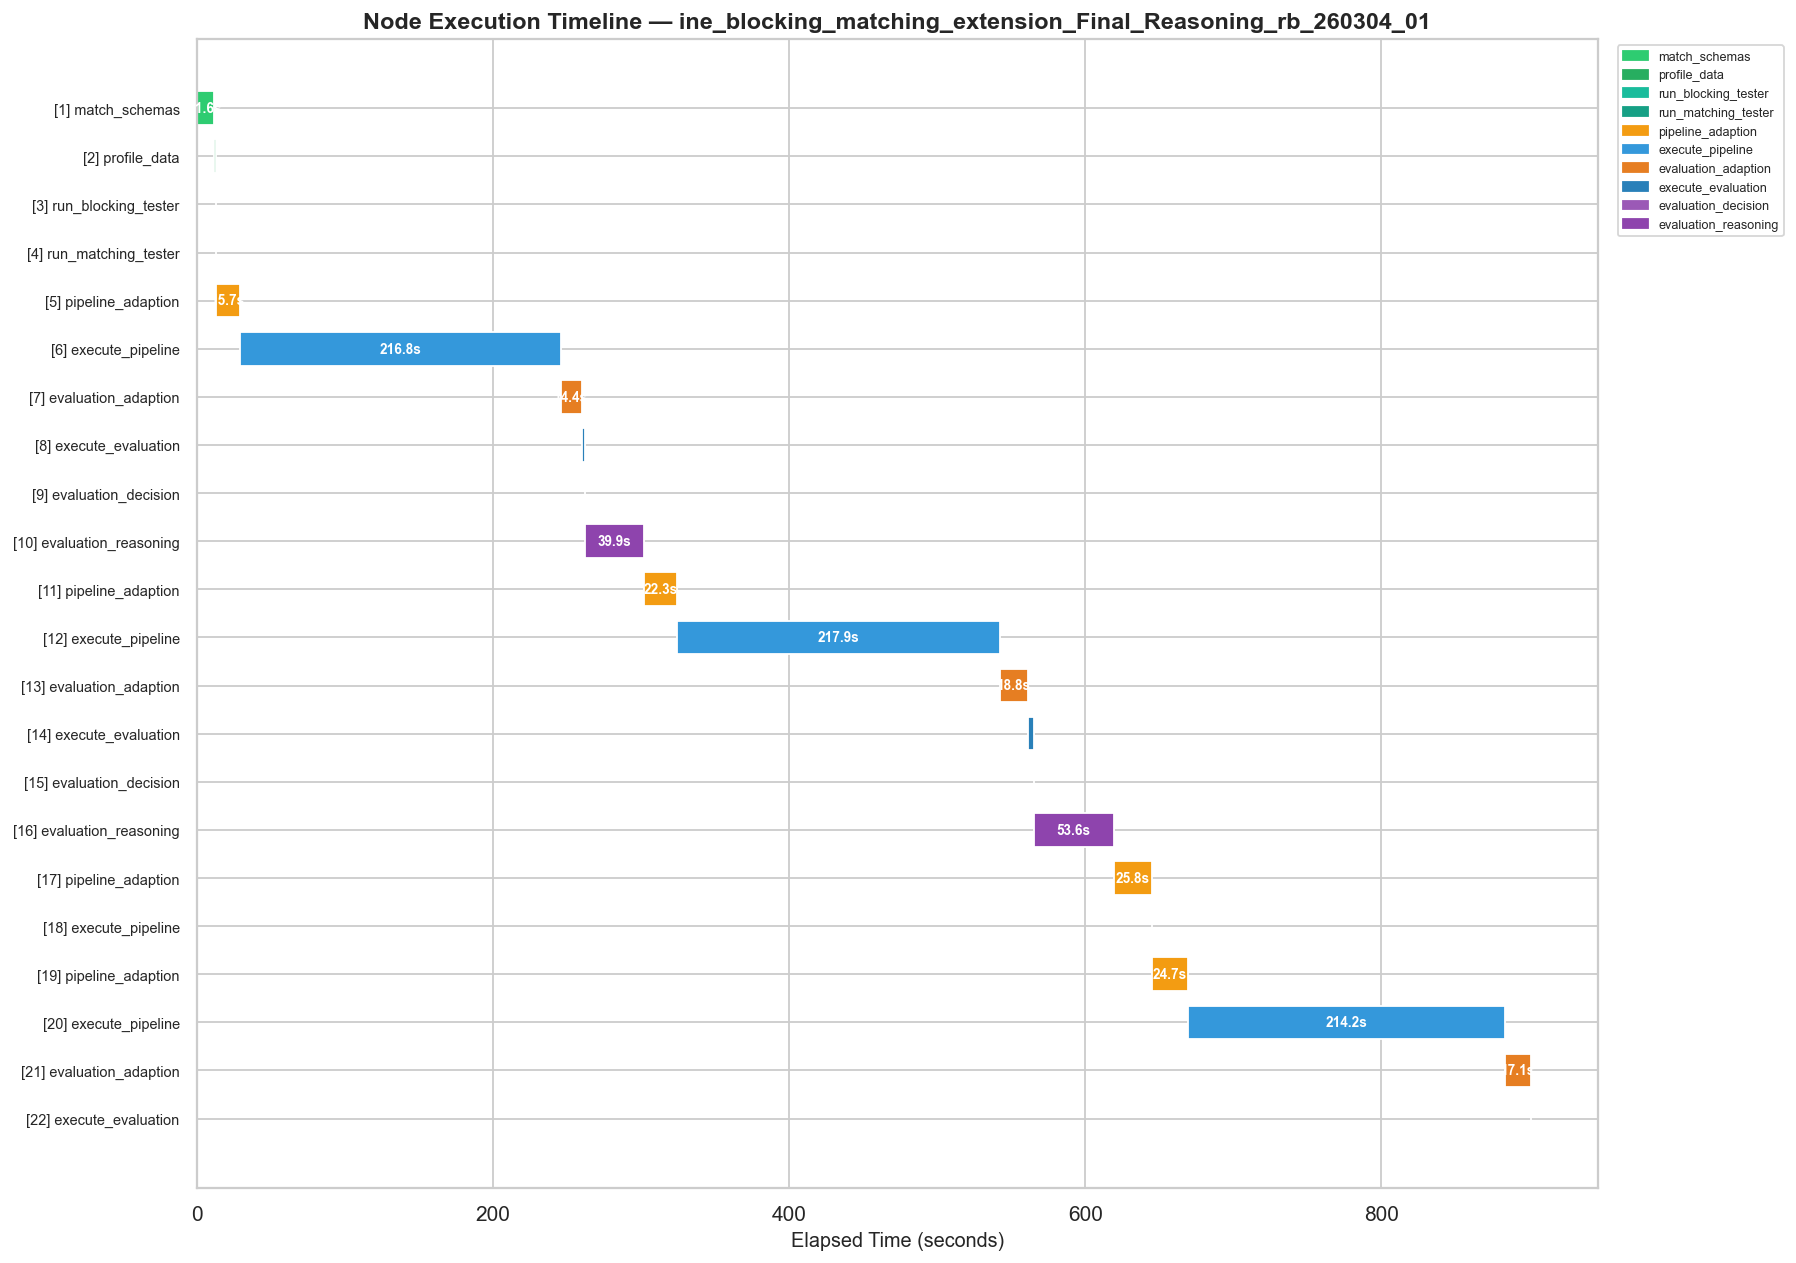

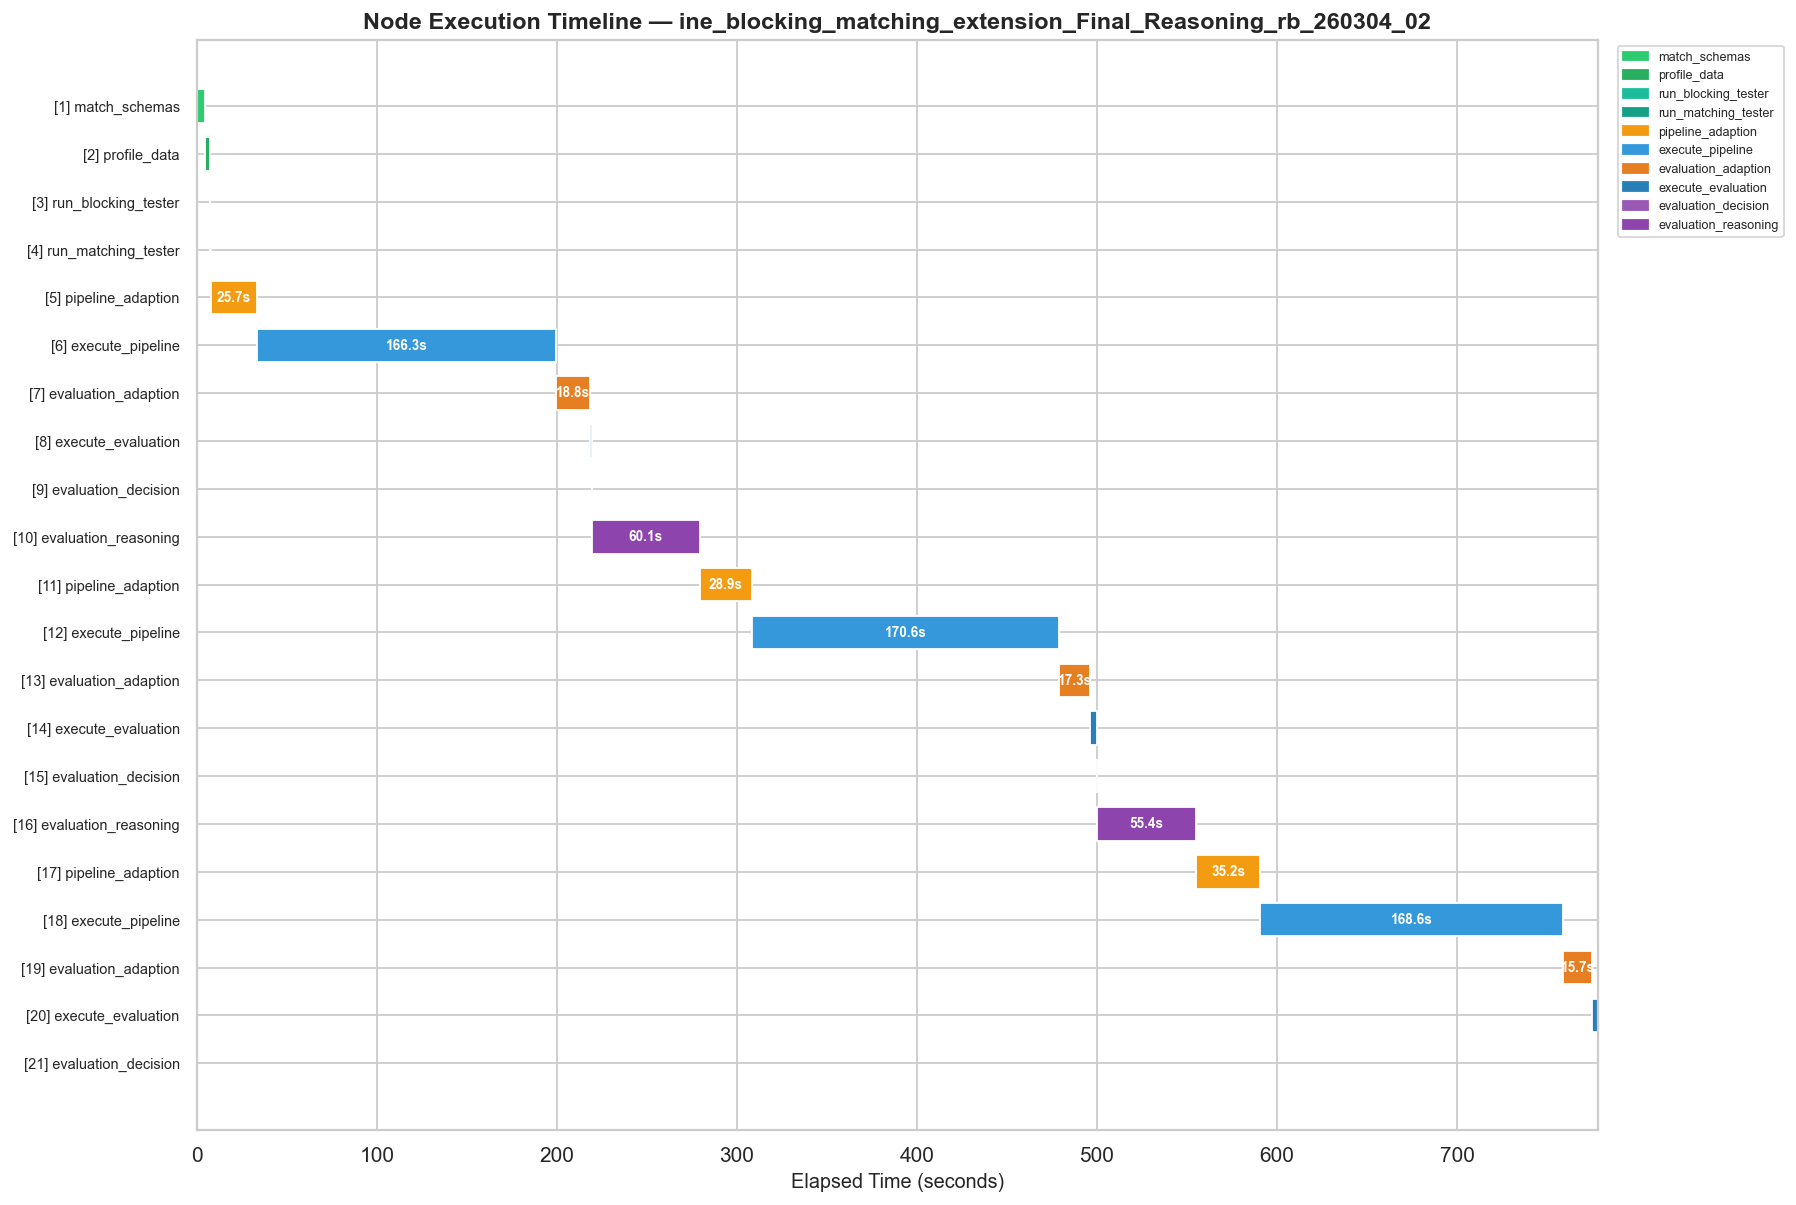

In [50]:
# Gantt-style timeline for each run
NODE_COLORS = {
    "match_schemas":         "#2ecc71",
    "profile_data":          "#27ae60",
    "run_blocking_tester":   "#1abc9c",
    "run_matching_tester":   "#16a085",
    "pipeline_adaption":     "#f39c12",
    "execute_pipeline":      "#3498db",
    "evaluation_adaption":   "#e67e22",
    "execute_evaluation":    "#2980b9",
    "evaluation_decision":   "#9b59b6",
    "evaluation_reasoning":  "#8e44ad",
}
DEFAULT_COLOR = "#95a5a6"

for run_id, r in runs.items():
    nodes_df = r["nodes"].sort_values("node_index").reset_index(drop=True)
    # Compute cumulative start times
    nodes_df["start"] = nodes_df["duration_seconds"].cumsum().shift(1).fillna(0)
    nodes_df["end"]   = nodes_df["start"] + nodes_df["duration_seconds"]

    fig, ax = plt.subplots(figsize=(14, max(4, len(nodes_df) * 0.45)))
    yticks, ylabels = [], []

    for i, row in nodes_df.iterrows():
        color = NODE_COLORS.get(row["current_node"], DEFAULT_COLOR)
        ax.barh(i, row["duration_seconds"], left=row["start"],
                color=color, edgecolor="white", height=0.7)
        # Label if wide enough
        if row["duration_seconds"] > 5:
            ax.text(row["start"] + row["duration_seconds"]/2, i,
                    f"{row['duration_seconds']:.1f}s",
                    va="center", ha="center", fontsize=7.5, color="white", fontweight="bold")
        yticks.append(i)
        ylabels.append(f"[{row['node_index']}] {row['current_node']}")

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_xlabel("Elapsed Time (seconds)")
    ax.set_title(f"Node Execution Timeline — {run_id[-60:]}", fontweight="bold")

    # Legend
    seen = {}
    for _, row in nodes_df.iterrows():
        n = row["current_node"]
        if n not in seen:
            seen[n] = NODE_COLORS.get(n, DEFAULT_COLOR)
    patches = [mpatches.Patch(color=c, label=n) for n, c in seen.items()]
    ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()